# 15. Optimización y selección de modelos finales

## 15.1. Objetivo

En los notebooks anteriores se entrenaron y compararon distintos algoritmos de clasificación para predecir los códigos de calidad asociados a las componentes GHI, DNI y DHI. Los resultados de estos experimentos se almacenaron en PostgreSQL y se utilizan en este notebook como punto de partida para seleccionar los candidatos que serán optimizados.

El objetivo es ajustar los hiperparámetros de los modelos seleccionados y obtener una configuración final para cada variable objetivo. La optimización se realiza exclusivamente con datos de 2024, reservando los registros de 2023 para la comparación interanual de las configuraciones finales.

Para GHI, donde existen dos candidatos competitivos, se incorpora además una validación temporal repetida dentro de 2024 para comparar Logistic Regression y MLP bajo las mismas particiones estacionales.

La métrica principal de selección es **Macro F1**, adecuada ante el desequilibrio entre clases, utilizando **Balanced Accuracy** y **Weighted F1** como métricas complementarias.

El proceso seguido comprende la recuperación de experimentos previos, definición de conjuntos de entrenamiento y validación, optimización de hiperparámetros, validación temporal de los candidatos GHI, selección de los modelos finales, reentrenamiento con todo 2024 y evaluación interanual sobre 2023.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
)

RANDOM_STATE = 42

TRAIN_YEAR = 2024
TEST_YEAR = 2023

TARGETS = [
    "codigo_ghi",
    "codigo_dni",
    "codigo_dhi"
]

PRIMARY_METRIC = "f1_macro"

DATA_PATH = Path(
    "../data/processed/dataset_solar_2023_2024_v3.parquet"
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## 15.2. Preparación de los datos

Se carga la versión procesada definitiva del dataset y se mantiene la separación temporal utilizada en los experimentos anteriores: **2024 como periodo de entrenamiento y 2023 como periodo de evaluación interanual**.

Las columnas de fecha, año y variables objetivo se excluyen del conjunto de variables predictoras. La selección concreta de features de cada modelo se recuperará posteriormente desde los experimentos almacenados.

In [3]:
df = pd.read_parquet(DATA_PATH)

print(f"Dataset completo: {df.shape}")
print(
    f"Periodo: {df['fecha'].min()} "
    f"→ {df['fecha'].max()}"
)

Dataset completo: (1052640, 27)
Periodo: 2023-01-01 00:00:00 → 2024-12-31 23:59:00


In [4]:
train_df = (
    df[df["ano"] == TRAIN_YEAR]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df[df["ano"] == TEST_YEAR]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Train ({TRAIN_YEAR}): "
    f"{train_df.shape}"
)

print(
    f"Test ({TEST_YEAR}): "
    f"{test_df.shape}"
)

Train (2024): (527040, 27)
Test (2023): (525600, 27)


In [5]:
EXCLUDED_COLUMNS = [
    "fecha",
    "ano",
    "codigo_ghi",
    "codigo_dni",
    "codigo_dhi"
]

CANDIDATE_FEATURES = [
    column
    for column in df.columns
    if column not in EXCLUDED_COLUMNS
]

print(
    f"Variables candidatas disponibles: "
    f"{len(CANDIDATE_FEATURES)}"
)

CANDIDATE_FEATURES

Variables candidatas disponibles: 22


['mes_sin',
 'mes_cos',
 'dia',
 'hora_sin',
 'hora_cos',
 'minuto',
 'ghi',
 'dni',
 'dhi',
 'ghi_estimado',
 'irr_null',
 'error_balance',
 'error_balance_abs',
 'error_balance_rel',
 'elevacion_solar',
 'periodo_solar',
 'temperatura',
 'velocidad_viento',
 'humedad_relativa',
 'direccion_viento_sin',
 'direccion_viento_cos',
 'var_meteo_imp']

## 15.3. Recuperación de experimentos previos

Los resultados obtenidos en la fase anterior de modelado se recuperan desde PostgreSQL. Esta información permite reutilizar las configuraciones, variables y métricas de los modelos ya evaluados sin repetir innecesariamente los entrenamientos.

A partir de estos experimentos se seleccionan los principales candidatos para la fase de optimización. Para GHI se mantienen MLP y Logistic Regression para realizar posteriormente una comparación más robusta, mientras que para DNI y DHI se seleccionan las variantes de HistGradientBoosting con mayor Macro F1.

En algunos experimentos anteriores se utilizó la etiqueta abreviada `HistGradientBoosting`; en este notebook el modelo definitivo se identifica de forma homogénea como `HistGradientBoostingClassifier`.

In [6]:
from src.database.postgresql_persistence import get_postgresql_connection

In [7]:
query_all_results = """
SELECT
    m.model_id,
    m.model_name,
    m.target,
    m.train_year,
    m.test_year,
    m.n_features,
    m.features,
    m.hyperparameters,
    r.f1_macro,
    r.balanced_accuracy,
    r.f1_weighted,
    r.created_at
FROM solar.models AS m
INNER JOIN solar.results AS r
    ON m.model_id = r.model_id
ORDER BY
    m.target,
    r.f1_macro DESC;
"""

conn = get_postgresql_connection()

try:
    all_results = pd.read_sql_query(
        query_all_results,
        conn
    )
finally:
    conn.close()

print(
    f"Número total de experimentos registrados: "
    f"{len(all_results)}"
)

all_results.head()

Número total de experimentos registrados: 18


C:\Users\zacar\AppData\Local\Temp\ipykernel_16756\3418399148.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  all_results = pd.read_sql_query(


,model_id,model_name,target,train_year,test_year,n_features,features,hyperparameters,f1_macro,balanced_accuracy,f1_weighted,created_at
0,3,HistGradientBoostingClassifier,codigo_dhi,2024,2023,22,"[mes_sin, mes_cos, dia, hora_sin, hora_cos, mi...","{'tol': 1e-07, 'loss': 'log_loss', 'scoring': ...",0.498600,0.572575,0.882477,2026-08-13 18:41:04.711730
1,21,HistGradientBoosting,codigo_dhi,2024,2023,18,"[mes_sin, mes_cos, dia, hora_sin, hora_cos, mi...","{'tol': 1e-07, 'loss': 'log_loss', 'scoring': ...",0.478681,0.555883,0.863185,2026-08-18 08:11:53.092781
2,24,MLP,codigo_dhi,2024,2023,14,"[mes_sin, mes_cos, dia, hora_sin, hora_cos, mi...","{'optimizer': 'Adam', 'activation': 'relu', 'b...",0.451350,0.515467,0.842825,2026-08-19 08:44:36.752629
3,18,RandomForest,codigo_dhi,2024,2023,14,"[mes_sin, mes_cos, dia, hora_sin, hora_cos, mi...","{'n_jobs': -1, 'verbose': 0, 'bootstrap': True...",0.450474,0.505040,0.847037,2026-08-18 08:11:42.893393
4,15,LogisticRegression,codigo_dhi,2024,2023,14,"[mes_sin, mes_cos, dia, hora_sin, hora_cos, mi...","{'C': 1.0, 'tol': 0.0001, 'dual': False, 'n_jo...",0.413080,0.560074,0.778568,2026-08-18 08:11:24.517424


In [8]:
results_summary = all_results[
    [
        "model_id",
        "target",
        "model_name",
        "n_features",
        "f1_macro",
        "balanced_accuracy",
        "f1_weighted"
    ]
].copy()

results_summary

,model_id,target,model_name,n_features,f1_macro,balanced_accuracy,f1_weighted
0,3,codigo_dhi,HistGradientBoostingClassifier,22,0.498600,0.572575,0.882477
1,21,codigo_dhi,HistGradientBoosting,18,0.478681,0.555883,0.863185
2,24,codigo_dhi,MLP,14,0.451350,0.515467,0.842825
3,18,codigo_dhi,RandomForest,14,0.450474,0.505040,0.847037
4,15,codigo_dhi,LogisticRegression,14,0.413080,0.560074,0.778568
5,12,codigo_dhi,DummyClassifier,0,0.313993,0.333333,0.838667
6,20,codigo_dni,HistGradientBoosting,18,0.534738,0.625648,0.940909
7,17,codigo_dni,RandomForest,14,0.489022,0.551082,0.927517
8,2,codigo_dni,HistGradientBoostingClassifier,22,0.486994,0.616805,0.932485
9,23,codigo_dni,MLP,14,0.462769,0.675691,0.904146


In [9]:
best_results = (
    all_results
    .sort_values(
        by=[
            "target",
            "f1_macro",
            "balanced_accuracy",
            "f1_weighted"
        ],
        ascending=[
            True,
            False,
            False,
            False
        ]
    )
    .drop_duplicates(
        subset="target",
        keep="first"
    )
    .reset_index(drop=True)
)

best_results[
    [
        "model_id",
        "target",
        "model_name",
        "n_features",
        "f1_macro",
        "balanced_accuracy",
        "f1_weighted"
    ]
]

,model_id,target,model_name,n_features,f1_macro,balanced_accuracy,f1_weighted
0,3,codigo_dhi,HistGradientBoostingClassifier,22,0.498600,0.572575,0.882477
1,20,codigo_dni,HistGradientBoosting,18,0.534738,0.625648,0.940909
2,22,codigo_ghi,MLP,14,0.743533,0.782470,0.883894


In [10]:
candidates_to_optimize = pd.concat([
    
    # GHI: dos mejores candidatos
    (
        all_results[
            all_results["target"] == "codigo_ghi"
        ]
        .sort_values("f1_macro", ascending=False)
        .head(2)
    ),
    
    # DNI: mejor candidato
    (
        all_results[
            all_results["target"] == "codigo_dni"
        ]
        .sort_values("f1_macro", ascending=False)
        .head(1)
    ),
    
    # DHI: mejor candidato
    (
        all_results[
            all_results["target"] == "codigo_dhi"
        ]
        .sort_values("f1_macro", ascending=False)
        .head(1)
    )
    
]).reset_index(drop=True)

candidates_to_optimize[
    [
        "model_id",
        "target",
        "model_name",
        "n_features",
        "f1_macro",
        "balanced_accuracy",
        "f1_weighted"
    ]
]

,model_id,target,model_name,n_features,f1_macro,balanced_accuracy,f1_weighted
0,22,codigo_ghi,MLP,14,0.743533,0.782470,0.883894
1,13,codigo_ghi,LogisticRegression,14,0.646299,0.810603,0.790116
2,20,codigo_dni,HistGradientBoosting,18,0.534738,0.625648,0.940909
3,3,codigo_dhi,HistGradientBoostingClassifier,22,0.498600,0.572575,0.882477


## 15.4. Diseño de la validación interna sobre 2024

La optimización de hiperparámetros debe realizarse sin utilizar los datos de 2023. Para ello se crea una partición temporal interna dentro de 2024.

Antes de definirla se analiza la distribución mensual de las clases de cada target. Esta comprobación es especialmente importante en DNI y DHI, donde las clases minoritarias no aparecen de forma homogénea durante todo el año.

In [11]:
train_df["mes_validation"] = train_df["fecha"].dt.month

monthly_target_distribution = {}

for target in TARGETS:
    monthly_distribution = pd.crosstab(
        train_df["mes_validation"],
        train_df[target],
        normalize="index"
    )

    monthly_target_distribution[target] = monthly_distribution

    print(f"\n{'=' * 70}")
    print(f"Distribución mensual de clases — {target}")
    print(f"{'=' * 70}")
    
    display(monthly_distribution.round(4))


Distribución mensual de clases — codigo_ghi


codigo_ghi,0,1
mes_validation,,
1,0.9979,0.0021
2,0.8465,0.1535
3,0.5476,0.4524
4,0.8638,0.1362
5,0.9026,0.0974
6,0.9429,0.0571
7,0.7765,0.2235
8,0.9800,0.0200
9,0.4329,0.5671



Distribución mensual de clases — codigo_dni


codigo_dni,0,1,2
mes_validation,,,
1,0.9959,0.0000,0.0041
2,0.8437,0.1552,0.0011
3,0.5471,0.4528,0.0002
4,0.8571,0.1385,0.0044
5,0.9004,0.0978,0.0019
6,0.9642,0.0337,0.0020
7,0.8052,0.1946,0.0002
8,0.9974,0.0015,0.0012
9,0.4329,0.5671,0.0000



Distribución mensual de clases — codigo_dhi


codigo_dhi,0,1,2
mes_validation,,,
1,0.9904,0.0096,0.0000
2,0.8415,0.1585,0.0000
3,0.5465,0.4524,0.0011
4,0.8539,0.1461,0.0000
5,0.7405,0.2595,0.0000
6,0.5669,0.4331,0.0000
7,0.7316,0.2649,0.0035
8,0.9080,0.0920,0.0000
9,0.4329,0.5671,0.0000


In [12]:
class_presence_by_month = []

for target in TARGETS:
    for month in sorted(train_df["mes_validation"].unique()):
        month_data = train_df.loc[
            train_df["mes_validation"] == month,
            target
        ]

        counts = month_data.value_counts()

        class_presence_by_month.append({
            "target": target,
            "mes_validation": month,
            "n_samples": len(month_data),
            "n_classes": month_data.nunique(),
            "classes": sorted(month_data.unique().tolist()),
            "min_class_count": counts.min()
        })

class_presence_by_month = pd.DataFrame(
    class_presence_by_month
)

class_presence_by_month

,target,mes_validation,n_samples,n_classes,classes,min_class_count
0,codigo_ghi,1,44640,2,"[0, 1]",94
1,codigo_ghi,2,41760,2,"[0, 1]",6409
2,codigo_ghi,3,44640,2,"[0, 1]",20194
3,codigo_ghi,4,43200,2,"[0, 1]",5885
4,codigo_ghi,5,44640,2,"[0, 1]",4350
5,codigo_ghi,6,43200,2,"[0, 1]",2468
6,codigo_ghi,7,44640,2,"[0, 1]",9976
7,codigo_ghi,8,44640,2,"[0, 1]",892
8,codigo_ghi,9,43200,2,"[0, 1]",18702
9,codigo_ghi,10,44640,2,"[0, 1]",1752


In [13]:
VALIDATION_MONTHS = [3, 8, 11]

optimization_train_df = (
    train_df[
        ~train_df["mes_validation"].isin(VALIDATION_MONTHS)
    ]
    .copy()
    .reset_index(drop=True)
)

validation_df = (
    train_df[
        train_df["mes_validation"].isin(VALIDATION_MONTHS)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Optimización/train: {optimization_train_df.shape}"
)

print(
    f"Validación:         {validation_df.shape}"
)

print(
    f"Total 2024:         "
    f"{len(optimization_train_df) + len(validation_df)}"
)

Optimización/train: (394560, 28)
Validación:         (132480, 28)
Total 2024:         527040


In [14]:
assert not set(
    optimization_train_df["fecha"]
).intersection(
    set(validation_df["fecha"])
)

assert (
    len(optimization_train_df)
    + len(validation_df)
    == len(train_df)
)

In [15]:
for target in TARGETS:

    print(f"\n{'=' * 70}")
    print(target)
    print(f"{'=' * 70}")

    comparison = pd.concat(
        [
            optimization_train_df[target]
            .value_counts()
            .sort_index()
            .rename("train_count"),

            validation_df[target]
            .value_counts()
            .sort_index()
            .rename("validation_count"),

            optimization_train_df[target]
            .value_counts(normalize=True)
            .sort_index()
            .rename("train_ratio"),

            validation_df[target]
            .value_counts(normalize=True)
            .sort_index()
            .rename("validation_ratio")
        ],
        axis=1
    )

    display(comparison)


codigo_ghi


,train_count,validation_count,train_ratio,validation_ratio
codigo_ghi,,,,
0,331678,105366,0.840628,0.795335
1,62882,27114,0.159372,0.204665



codigo_dni


,train_count,validation_count,train_ratio,validation_ratio
codigo_dni,,,,
0,333635,106275,0.845587,0.802197
1,60224,26063,0.152636,0.196732
2,701,142,0.001777,0.001072



codigo_dhi


,train_count,validation_count,train_ratio,validation_ratio
codigo_dhi,,,,
0,298008,94044,0.755292,0.709873
1,96396,38386,0.244313,0.289749
2,156,50,0.000395,0.000377


In [16]:
for target in TARGETS:

    train_classes = set(
        optimization_train_df[target].unique()
    )

    validation_classes = set(
        validation_df[target].unique()
    )

    print(
        f"{target}: "
        f"train={sorted(train_classes)} | "
        f"validation={sorted(validation_classes)}"
    )

    assert train_classes == validation_classes

codigo_ghi: train=[np.int64(0), np.int64(1)] | validation=[np.int64(0), np.int64(1)]
codigo_dni: train=[np.int64(0), np.int64(1), np.int64(2)] | validation=[np.int64(0), np.int64(1), np.int64(2)]
codigo_dhi: train=[np.int64(0), np.int64(1), np.int64(2)] | validation=[np.int64(0), np.int64(1), np.int64(2)]


Se seleccionan **marzo, agosto y noviembre** como conjunto de validación inicial. Esta combinación mantiene representación de todas las clases presentes en los tres targets tanto en entrenamiento como en validación.

La partición resultante contiene 394.560 observaciones para entrenamiento y 132.480 para validación. La separación es estrictamente temporal y `mes_validation` se utiliza únicamente para construir los subconjuntos, sin incorporarse como variable predictora.

## 15.5. Preprocesamiento específico por modelo

Cada candidato conserva las variables utilizadas en su experimento original. El preprocesamiento se adapta posteriormente a las características del algoritmo: los modelos lineales y la red neuronal requieren datos completos y escalados, mientras que `HistGradientBoostingClassifier` admite valores ausentes y no necesita estandarización.

Las variables booleanas y categóricas se convierten previamente a representación numérica para garantizar una entrada homogénea en los algoritmos.

In [17]:
from src.preprocessing.model_preprocessing import convert_model_dtypes, prepare_model_features

MODEL_PREPROCESSING = {
    "MLP": {
        "accepts_nan": False,
        "scale": True,
    },
    "LogisticRegression": {
        "accepts_nan": False,
        "scale": True,
    },
    "HistGradientBoosting": {
        "accepts_nan": True,
        "scale": False,
    },
    "HistGradientBoostingClassifier": {
        "accepts_nan": True,
        "scale": False,
    },
}

In [18]:
optimization_train_df = convert_model_dtypes(
    optimization_train_df
)

validation_df = convert_model_dtypes(
    validation_df
)

optimization_train_df.dtypes

ano                              int64
mes_sin                        float64
mes_cos                        float64
dia                              int64
hora_sin                       float64
hora_cos                       float64
minuto                           int64
fecha                   datetime64[us]
ghi                            float64
dni                            float64
dhi                            float64
ghi_estimado                   float64
irr_null                          int8
error_balance                  float64
error_balance_abs              float64
error_balance_rel              float64
elevacion_solar                float64
periodo_solar                     int8
temperatura                    float64
velocidad_viento               float64
humedad_relativa               float64
direccion_viento_sin           float64
direccion_viento_cos           float64
var_meteo_imp                     int8
codigo_ghi                       int64
codigo_dni               

In [19]:
optimization_data = {}

for _, row in candidates_to_optimize.iterrows():

    model_id = int(row["model_id"])
    model_name = row["model_name"]
    target = row["target"]

    features = list(row["features"])

    preprocessing_config = MODEL_PREPROCESSING[
        model_name
    ]

    (
        X_train_opt,
        X_val,
        used_features,
        scaler,
    ) = prepare_model_features(
        train_df=optimization_train_df,
        test_df=validation_df,
        features=features,
        accepts_nan=preprocessing_config["accepts_nan"],
        scale=preprocessing_config["scale"],
    )

    y_train_opt = (
        optimization_train_df[target]
        .copy()
        .reset_index(drop=True)
    )

    y_val = (
        validation_df[target]
        .copy()
        .reset_index(drop=True)
    )

    X_train_opt = X_train_opt.reset_index(drop=True)
    X_val = X_val.reset_index(drop=True)

    optimization_data[model_id] = {
        "model_id": model_id,
        "model_name": model_name,
        "target": target,
        "original_features": features,
        "used_features": used_features,
        "X_train": X_train_opt,
        "X_val": X_val,
        "y_train": y_train_opt,
        "y_val": y_val,
        "scaler": scaler,
        "baseline_f1_2023": row["f1_macro"],
        "baseline_balanced_accuracy_2023": (
            row["balanced_accuracy"]
        ),
        "baseline_f1_weighted_2023": (
            row["f1_weighted"]
        ),
        "original_hyperparameters": (
            row["hyperparameters"]
        ),
    }

In [20]:
preparation_summary = []

for model_id, data in optimization_data.items():

    preparation_summary.append({
        "model_id": model_id,
        "target": data["target"],
        "model_name": data["model_name"],
        "n_original_features": len(
            data["original_features"]
        ),
        "n_used_features": len(
            data["used_features"]
        ),
        "train_samples": len(
            data["X_train"]
        ),
        "validation_samples": len(
            data["X_val"]
        ),
        "train_nan": (
            data["X_train"]
            .isna()
            .sum()
            .sum()
        ),
        "validation_nan": (
            data["X_val"]
            .isna()
            .sum()
            .sum()
        ),
    })

preparation_summary = pd.DataFrame(
    preparation_summary
)

preparation_summary

,model_id,target,model_name,n_original_features,n_used_features,train_samples,validation_samples,train_nan,validation_nan
0,22,codigo_ghi,MLP,14,14,394560,132480,0,0
1,13,codigo_ghi,LogisticRegression,14,14,394560,132480,0,0
2,20,codigo_dni,HistGradientBoosting,18,18,394560,132480,245648,165007
3,3,codigo_dhi,HistGradientBoostingClassifier,22,21,394560,132480,247127,193771


## 15.6. Optimización de HistGradientBoosting

Para DNI y DHI se realiza una búsqueda aleatoria de hiperparámetros sobre las configuraciones de `HistGradientBoostingClassifier`. Se exploran parámetros relacionados con la tasa de aprendizaje, complejidad de los árboles, número de iteraciones, tamaño mínimo de hoja y regularización.

Cada configuración se entrena con el subconjunto de entrenamiento de 2024 y se evalúa sobre los meses reservados de validación. Los resultados se almacenan en disco para evitar repetir el proceso en ejecuciones posteriores.

In [21]:
from time import perf_counter

from sklearn.ensemble import HistGradientBoostingClassifier

In [22]:
OPTIMIZATION_OUTPUT_PATH = Path(
    "../outputs/tables/model_optimization"
)

OPTIMIZATION_OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

HGB_DNI_RESULTS_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "hgb_dni_tuning.parquet"
)

HGB_DHI_RESULTS_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "hgb_dhi_tuning.parquet"
)

FORCE_RETRAIN_HGB = False

In [23]:
hgb_param_space = {
    "learning_rate": [0.03, 0.05, 0.08, 0.10, 0.15],
    "max_iter": [100, 200, 300, 500],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [10, 20, 40, 80],
    "l2_regularization": [0.0, 0.1, 1.0, 5.0, 10.0]
}

In [24]:
def optimize_hgb(
    data,
    param_space,
    n_iter=25,
    random_state=42
):

    X_train = data["X_train"]
    X_val = data["X_val"]
    y_train = data["y_train"]
    y_val = data["y_val"]

    sampled_params = list(
        ParameterSampler(
            param_space,
            n_iter=n_iter,
            random_state=random_state
        )
    )

    results = []

    for i, params in enumerate(sampled_params, start=1):

        start_time = perf_counter()

        model = HistGradientBoostingClassifier(
            **params,
            random_state=random_state
        )

        model.fit(
            X_train,
            y_train
        )

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        train_f1_macro = f1_score(
            y_train,
            y_train_pred,
            average="macro",
            zero_division=0
        )

        val_f1_macro = f1_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        )

        val_balanced_accuracy = balanced_accuracy_score(
            y_val,
            y_val_pred
        )

        val_f1_weighted = f1_score(
            y_val,
            y_val_pred,
            average="weighted",
            zero_division=0
        )

        elapsed_time = perf_counter() - start_time

        results.append({
            "iteration": i,
            **params,
            "train_f1_macro": train_f1_macro,
            "val_f1_macro": val_f1_macro,
            "overfit_gap": (
                train_f1_macro - val_f1_macro
            ),
            "val_balanced_accuracy": (
                val_balanced_accuracy
            ),
            "val_f1_weighted": (
                val_f1_weighted
            ),
            "training_time_s": elapsed_time
        })

        print(
            f"{i:02d}/{len(sampled_params)} | "
            f"Val F1 macro: {val_f1_macro:.4f} | "
            f"Gap: {train_f1_macro - val_f1_macro:.4f}"
        )

    results_df = pd.DataFrame(results)

    results_df = (
        results_df
        .sort_values(
            by=[
                "val_f1_macro",
                "val_balanced_accuracy",
                "val_f1_weighted"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )

    return results_df

In [25]:
hgb_candidates = {
    model_id: data
    for model_id, data in optimization_data.items()
    if "HistGradientBoosting" in data["model_name"]
}

for model_id, data in hgb_candidates.items():

    print(
        f"Model ID: {model_id} | "
        f"Target: {data['target']} | "
        f"Modelo: {data['model_name']}"
    )

Model ID: 20 | Target: codigo_dni | Modelo: HistGradientBoosting
Model ID: 3 | Target: codigo_dhi | Modelo: HistGradientBoostingClassifier


In [26]:
dni_hgb_id = next(
    model_id
    for model_id, data in hgb_candidates.items()
    if data["target"] == "codigo_dni"
)

if (
    HGB_DNI_RESULTS_PATH.exists()
    and not FORCE_RETRAIN_HGB
):

    print(
        "Cargando resultados existentes "
        "de HGB para codigo_dni..."
    )

    hgb_dni_results = pd.read_parquet(
        HGB_DNI_RESULTS_PATH
    )

else:

    print(
        "Ejecutando optimización de HGB "
        "para codigo_dni..."
    )

    hgb_dni_results = optimize_hgb(
        data=optimization_data[dni_hgb_id],
        param_space=hgb_param_space,
        n_iter=25,
        random_state=RANDOM_STATE
    )

    hgb_dni_results.to_parquet(
        HGB_DNI_RESULTS_PATH,
        index=False
    )

    print(
        f"Resultados guardados en: "
        f"{HGB_DNI_RESULTS_PATH}"
    )

Cargando resultados existentes de HGB para codigo_dni...


In [27]:
hgb_dni_results.head(10)

,iteration,min_samples_leaf,max_leaf_nodes,max_iter,max_depth,learning_rate,l2_regularization,train_f1_macro,val_f1_macro,overfit_gap,val_balanced_accuracy,val_f1_weighted,training_time_s
0,19,40,31,500,5.0,0.08,0.0,0.776347,0.674742,0.101605,0.675225,0.975786,2.640269
1,4,40,63,300,5.0,0.08,0.0,0.777989,0.674228,0.103761,0.675209,0.975765,2.818369
2,1,10,63,500,5.0,0.15,0.0,0.740043,0.638132,0.101911,0.637514,0.970828,2.253829
3,11,20,15,100,NaN,0.15,0.0,0.851244,0.629897,0.221346,0.659281,0.935947,2.402567
4,13,20,63,300,10.0,0.08,1.0,0.997572,0.623700,0.373871,0.635374,0.952698,26.851511
5,5,40,63,100,NaN,0.10,10.0,0.997506,0.618308,0.379198,0.632490,0.951719,19.263198
6,2,10,31,300,10.0,0.15,5.0,0.997815,0.616665,0.381150,0.630809,0.950180,30.088123
7,9,40,63,300,10.0,0.03,0.0,0.997571,0.610910,0.386661,0.630261,0.939381,49.264796
8,25,40,31,300,5.0,0.15,0.1,0.980315,0.610264,0.370051,0.662346,0.927796,35.152074
9,3,10,63,200,NaN,0.05,5.0,0.998016,0.610105,0.387911,0.628800,0.943281,34.333059


In [28]:
dhi_hgb_id = next(
    model_id
    for model_id, data in hgb_candidates.items()
    if data["target"] == "codigo_dhi"
)

if (
    HGB_DHI_RESULTS_PATH.exists()
    and not FORCE_RETRAIN_HGB
):

    print(
        "Cargando resultados existentes "
        "de HGB para codigo_dhi..."
    )

    hgb_dhi_results = pd.read_parquet(
        HGB_DHI_RESULTS_PATH
    )

else:

    print(
        "Ejecutando optimización de HGB "
        "para codigo_dhi..."
    )

    hgb_dhi_results = optimize_hgb(
        data=optimization_data[dhi_hgb_id],
        param_space=hgb_param_space,
        n_iter=25,
        random_state=RANDOM_STATE
    )

    hgb_dhi_results.to_parquet(
        HGB_DHI_RESULTS_PATH,
        index=False
    )

    print(
        f"Resultados guardados en: "
        f"{HGB_DHI_RESULTS_PATH}"
    )

Cargando resultados existentes de HGB para codigo_dhi...


In [29]:
hgb_dhi_results.head(10)

,iteration,min_samples_leaf,max_leaf_nodes,max_iter,max_depth,learning_rate,l2_regularization,train_f1_macro,val_f1_macro,overfit_gap,val_balanced_accuracy,val_f1_weighted,training_time_s
0,1,10,63,500,5.0,0.15,0.0,0.661159,0.573442,0.087716,0.561731,0.887394,2.224121
1,4,40,63,300,5.0,0.08,0.0,0.772696,0.571140,0.201556,0.554959,0.885785,2.701953
2,19,40,31,500,5.0,0.08,0.0,0.772696,0.571140,0.201556,0.554959,0.885785,2.772486
3,11,20,15,100,NaN,0.15,0.0,0.774794,0.566881,0.207913,0.560479,0.878133,2.548380
4,9,40,63,300,10.0,0.03,0.0,0.774970,0.536424,0.238546,0.548711,0.832777,15.380884
5,3,10,63,200,NaN,0.05,5.0,0.998628,0.531380,0.467247,0.545651,0.826918,35.537108
6,5,40,63,100,NaN,0.10,10.0,0.993091,0.531008,0.462083,0.546052,0.826140,19.081350
7,22,80,31,300,10.0,0.03,1.0,0.998651,0.528822,0.469829,0.544928,0.822834,41.139132
8,23,80,63,100,5.0,0.15,1.0,0.998601,0.527721,0.470879,0.539896,0.822992,14.828369
9,21,40,15,200,5.0,0.10,1.0,0.998155,0.527568,0.470587,0.536928,0.823949,22.702374


In [30]:
best_hgb_results = pd.DataFrame([
    {
        "target": "codigo_dni",
        **hgb_dni_results.iloc[0].to_dict()
    },
    {
        "target": "codigo_dhi",
        **hgb_dhi_results.iloc[0].to_dict()
    }
])

best_hgb_results[
    [
        "target",
        "val_f1_macro",
        "train_f1_macro",
        "overfit_gap",
        "val_balanced_accuracy",
        "val_f1_weighted",
        "learning_rate",
        "max_iter",
        "max_leaf_nodes",
        "max_depth",
        "min_samples_leaf",
        "l2_regularization"
    ]
]

,target,val_f1_macro,train_f1_macro,overfit_gap,val_balanced_accuracy,val_f1_weighted,learning_rate,max_iter,max_leaf_nodes,max_depth,min_samples_leaf,l2_regularization
0,codigo_dni,0.674742,0.776347,0.101605,0.675225,0.975786,0.08,500.0,31.0,5.0,40.0,0.0
1,codigo_dhi,0.573442,0.661159,0.087716,0.561731,0.887394,0.15,500.0,63.0,5.0,10.0,0.0


Los mejores resultados de validación alcanzan un **Macro F1 de 0,6747 para DNI** y **0,5734 para DHI**. Los gaps entre entrenamiento y validación son de aproximadamente 0,10 y 0,09 respectivamente, claramente inferiores a los observados en varias configuraciones más complejas.

En ambos casos se seleccionan configuraciones con profundidad máxima de 5 y sin regularización L2 adicional. Los elevados valores de Weighted F1 frente a Macro F1 confirman el efecto del fuerte desequilibrio entre clases y justifican mantener Macro F1 como criterio principal.

## 15.7. Optimización de los candidatos para GHI

### 15.7.1. Screening inicial

Para GHI se mantienen dos candidatos: Logistic Regression y MLP. Ambos se optimizan inicialmente utilizando la partición temporal marzo-agosto-noviembre.

Esta primera búsqueda actúa como **screening de configuraciones**. Debido a que el rendimiento puede depender notablemente de los meses utilizados como validación, la decisión final entre ambos algoritmos se realizará posteriormente mediante una validación temporal común más robusta.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterSampler

LR_GHI_RESULTS_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "lr_ghi_tuning.parquet"
)

FORCE_RETRAIN_LR = False

In [32]:
lr_param_space = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": np.logspace(-3, 2, 12),
        "class_weight": [None, "balanced"],
        "max_iter": [1000]
    },
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": np.logspace(-3, 2, 12),
        "class_weight": [None, "balanced"],
        "max_iter": [1000]
    }
]

In [33]:
def optimize_logistic_regression(
    data,
    param_space,
    n_iter=30,
    random_state=42
):

    X_train = data["X_train"]
    X_val = data["X_val"]
    y_train = data["y_train"]
    y_val = data["y_val"]

    sampled_params = list(
        ParameterSampler(
            param_space,
            n_iter=n_iter,
            random_state=random_state
        )
    )

    results = []

    for i, params in enumerate(
        sampled_params,
        start=1
    ):

        start_time = perf_counter()

        model = LogisticRegression(
            **params,
            random_state=random_state
        )

        model.fit(
            X_train,
            y_train
        )

        y_train_pred = model.predict(
            X_train
        )

        y_val_pred = model.predict(
            X_val
        )

        train_f1_macro = f1_score(
            y_train,
            y_train_pred,
            average="macro",
            zero_division=0
        )

        val_f1_macro = f1_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        )

        val_balanced_accuracy = (
            balanced_accuracy_score(
                y_val,
                y_val_pred
            )
        )

        val_f1_weighted = f1_score(
            y_val,
            y_val_pred,
            average="weighted",
            zero_division=0
        )

        elapsed_time = (
            perf_counter()
            - start_time
        )

        results.append({
            "iteration": i,
            **params,
            "train_f1_macro": train_f1_macro,
            "val_f1_macro": val_f1_macro,
            "overfit_gap": (
                train_f1_macro
                - val_f1_macro
            ),
            "val_balanced_accuracy": (
                val_balanced_accuracy
            ),
            "val_f1_weighted": (
                val_f1_weighted
            ),
            "training_time_s": (
                elapsed_time
            )
        })

        print(
            f"{i:02d}/{len(sampled_params)} | "
            f"Val F1 macro: "
            f"{val_f1_macro:.4f} | "
            f"Gap: "
            f"{train_f1_macro - val_f1_macro:.4f}"
        )

    results_df = pd.DataFrame(
        results
    )

    results_df = (
        results_df
        .sort_values(
            by=[
                "val_f1_macro",
                "val_balanced_accuracy",
                "val_f1_weighted"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )

    return results_df

In [34]:
lr_ghi_id = next(
    model_id
    for model_id, data
    in optimization_data.items()
    if (
        data["target"] == "codigo_ghi"
        and data["model_name"]
        == "LogisticRegression"
    )
)

print(
    f"Model ID: {lr_ghi_id} | "
    f"Target: "
    f"{optimization_data[lr_ghi_id]['target']} | "
    f"Modelo: "
    f"{optimization_data[lr_ghi_id]['model_name']}"
)

Model ID: 13 | Target: codigo_ghi | Modelo: LogisticRegression


In [35]:
if (
    LR_GHI_RESULTS_PATH.exists()
    and not FORCE_RETRAIN_LR
):

    print(
        "Cargando resultados existentes "
        "de Logistic Regression "
        "para codigo_ghi..."
    )

    lr_ghi_results = pd.read_parquet(
        LR_GHI_RESULTS_PATH
    )

else:

    print(
        "Ejecutando optimización de "
        "Logistic Regression "
        "para codigo_ghi..."
    )

    lr_ghi_results = (
        optimize_logistic_regression(
            data=optimization_data[
                lr_ghi_id
            ],
            param_space=lr_param_space,
            n_iter=30,
            random_state=RANDOM_STATE
        )
    )

    lr_ghi_results.to_parquet(
        LR_GHI_RESULTS_PATH,
        index=False
    )

    print(
        f"Resultados guardados en: "
        f"{LR_GHI_RESULTS_PATH}"
    )

Cargando resultados existentes de Logistic Regression para codigo_ghi...


In [36]:
lr_ghi_results.head(10)

,iteration,solver,penalty,max_iter,class_weight,C,train_f1_macro,val_f1_macro,overfit_gap,val_balanced_accuracy,val_f1_weighted,training_time_s
0,19,liblinear,l2,1000,NaN,0.008111,0.655541,0.678521,-0.022979,0.642665,0.817458,1.359131
1,7,lbfgs,l2,1000,NaN,0.187382,0.654986,0.677778,-0.022792,0.642218,0.816950,0.773783
2,9,lbfgs,l2,1000,NaN,0.533670,0.654936,0.677767,-0.022832,0.642217,0.816937,0.767323
3,1,lbfgs,l2,1000,NaN,0.008111,0.655695,0.677762,-0.022068,0.642084,0.817069,0.808046
4,16,lbfgs,l2,1000,NaN,100.000000,0.654934,0.677737,-0.022803,0.642190,0.816925,0.764119
5,3,lbfgs,l2,1000,NaN,12.328467,0.654934,0.677728,-0.022794,0.642185,0.816919,0.763198
6,22,lbfgs,l2,1000,NaN,4.328761,0.654934,0.677728,-0.022794,0.642185,0.816919,0.761846
7,14,liblinear,l2,1000,NaN,0.187382,0.654897,0.677700,-0.022802,0.642154,0.816914,1.272729
8,24,liblinear,l1,1000,NaN,0.187382,0.654863,0.677623,-0.022760,0.642085,0.816885,11.694861
9,25,liblinear,l2,1000,NaN,100.000000,0.654833,0.677575,-0.022742,0.642074,0.816833,1.279999


La mejor configuración inicial de Logistic Regression obtiene un **Macro F1 de 0,6785**, con Balanced Accuracy de 0,6427. La configuración utiliza regularización L2, `liblinear`, `C = 0,0081` y no aplica ponderación de clases.

El resultado constituye únicamente una primera referencia, ya que procede de una única partición temporal.

### 15.7.2. Optimización inicial del MLP

Para la red neuronal se exploran distintas arquitecturas, tasas de dropout, regularización L2, tasas de aprendizaje, tamaños de batch y estrategias de ponderación de clases.

El entrenamiento incorpora `EarlyStopping` para limitar el sobreajuste y recuperar los pesos correspondientes al mejor comportamiento sobre validación. Las funciones específicas del modelo se mantienen centralizadas en el módulo `src.models.mlp`.

In [38]:
import json
import tensorflow as tf

from src.models.mlp import (
    build_optimized_mlp,
    optimize_mlp,
)

In [39]:
MLP_GHI_RESULTS_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "mlp_ghi_tuning.parquet"
)

FORCE_RETRAIN_MLP = False

In [40]:
mlp_ghi_id = next(
    model_id
    for model_id, data in optimization_data.items()
    if (
        data["target"] == "codigo_ghi"
        and data["model_name"] == "MLP"
    )
)

print(
    f"Model ID: {mlp_ghi_id} | "
    f"Target: {optimization_data[mlp_ghi_id]['target']} | "
    f"Modelo: {optimization_data[mlp_ghi_id]['model_name']}"
)

Model ID: 22 | Target: codigo_ghi | Modelo: MLP


In [41]:
mlp_param_space = {
    "hidden_units": [
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32),
        (256, 128, 64)
    ],
    "dropout_rate": [
        0.1,
        0.2,
        0.3,
        0.4,
        0.5
    ],
    "l2_strength": [
        0.0,
        1e-5,
        1e-4,
        1e-3
    ],
    "learning_rate": [
        1e-4,
        3e-4,
        1e-3
    ],
    "batch_size": [
        512,
        1024,
        2048
    ],
    "class_weight_mode": [
        "none",
        "balanced"
    ]
}

In [42]:
if (
    MLP_GHI_RESULTS_PATH.exists()
    and not FORCE_RETRAIN_MLP
):

    print(
        "Cargando resultados existentes "
        "del MLP para codigo_ghi..."
    )

    mlp_ghi_results = pd.read_parquet(
        MLP_GHI_RESULTS_PATH
    )

else:

    print(
        "Ejecutando optimización del "
        "MLP para codigo_ghi..."
    )

    mlp_ghi_results = optimize_mlp(
        data=optimization_data[
            mlp_ghi_id
        ],
        param_space=mlp_param_space,
        n_iter=15,
        max_epochs=100,
        patience=8,
        random_state=RANDOM_STATE
    )

    mlp_ghi_results.to_parquet(
        MLP_GHI_RESULTS_PATH,
        index=False
    )

    print(
        f"Resultados guardados en: "
        f"{MLP_GHI_RESULTS_PATH}"
    )

Cargando resultados existentes del MLP para codigo_ghi...


In [43]:
mlp_ghi_results.head(10)

,iteration,hidden_units,dropout_rate,l2_strength,learning_rate,batch_size,class_weight_mode,epochs_trained,best_epoch,best_val_loss,train_f1_macro,val_f1_macro,overfit_gap,val_balanced_accuracy,val_f1_weighted,training_time_s
0,5,"[128, 64, 32]",0.3,0.00010,0.0001,2048,none,14,6,0.398113,0.732697,0.777925,-0.045229,0.732300,0.868106,17.892930
1,9,"[128, 64]",0.1,0.00010,0.0001,2048,none,12,4,0.414235,0.693923,0.748232,-0.054309,0.703711,0.852291,12.013851
2,8,"[128, 64]",0.5,0.00010,0.0001,512,none,11,3,0.407631,0.753644,0.748042,0.005602,0.711284,0.849104,25.018078
3,13,"[128, 64, 32]",0.1,0.00000,0.0003,1024,none,9,1,0.402295,0.787989,0.742822,0.045166,0.718306,0.841473,15.385577
4,14,[64],0.2,0.00001,0.0001,2048,none,46,38,0.386761,0.827501,0.731197,0.096303,0.722207,0.828458,26.784552
5,12,"[64, 32]",0.4,0.00001,0.0010,2048,none,9,1,0.412693,0.684144,0.705659,-0.021516,0.669143,0.828078,7.937252
6,11,"[128, 64, 32]",0.2,0.00100,0.0003,512,none,9,1,0.500616,0.820632,0.686293,0.134339,0.685839,0.795991,22.943147
7,1,"[256, 128, 64]",0.2,0.00010,0.0010,1024,none,9,1,0.798476,0.920676,0.608474,0.312203,0.634477,0.721722,22.533111
8,4,[128],0.1,0.00001,0.0001,1024,balanced,23,15,0.606006,0.773420,0.607702,0.165719,0.687661,0.689748,27.739469
9,6,"[64, 32]",0.2,0.00100,0.0003,512,balanced,9,1,0.652098,0.725677,0.605979,0.119698,0.652338,0.706150,19.551040


In [44]:
display(
    mlp_ghi_results[
        [
            "val_f1_macro",
            "train_f1_macro",
            "overfit_gap",
            "val_balanced_accuracy",
            "val_f1_weighted",
            "hidden_units",
            "dropout_rate",
            "l2_strength",
            "learning_rate",
            "batch_size",
            "class_weight_mode",
            "best_epoch",
            "epochs_trained"
        ]
    ].head(10)
)

,val_f1_macro,train_f1_macro,overfit_gap,val_balanced_accuracy,val_f1_weighted,hidden_units,dropout_rate,l2_strength,learning_rate,batch_size,class_weight_mode,best_epoch,epochs_trained
0,0.777925,0.732697,-0.045229,0.732300,0.868106,"[128, 64, 32]",0.3,0.00010,0.0001,2048,none,6,14
1,0.748232,0.693923,-0.054309,0.703711,0.852291,"[128, 64]",0.1,0.00010,0.0001,2048,none,4,12
2,0.748042,0.753644,0.005602,0.711284,0.849104,"[128, 64]",0.5,0.00010,0.0001,512,none,3,11
3,0.742822,0.787989,0.045166,0.718306,0.841473,"[128, 64, 32]",0.1,0.00000,0.0003,1024,none,1,9
4,0.731197,0.827501,0.096303,0.722207,0.828458,[64],0.2,0.00001,0.0001,2048,none,38,46
5,0.705659,0.684144,-0.021516,0.669143,0.828078,"[64, 32]",0.4,0.00001,0.0010,2048,none,1,9
6,0.686293,0.820632,0.134339,0.685839,0.795991,"[128, 64, 32]",0.2,0.00100,0.0003,512,none,1,9
7,0.608474,0.920676,0.312203,0.634477,0.721722,"[256, 128, 64]",0.2,0.00010,0.0010,1024,none,1,9
8,0.607702,0.773420,0.165719,0.687661,0.689748,[128],0.1,0.00001,0.0001,1024,balanced,15,23
9,0.605979,0.725677,0.119698,0.652338,0.706150,"[64, 32]",0.2,0.00100,0.0003,512,balanced,1,9


El mejor resultado del screening inicial alcanza un **Macro F1 de 0,7779**, superior al obtenido por Logistic Regression en esta partición. Sin embargo, las configuraciones muestran diferencias relevantes de rendimiento y de época óptima, lo que indica sensibilidad al periodo utilizado como validación.

Por este motivo, el resultado de esta única partición no se utiliza directamente para seleccionar la arquitectura final.

In [45]:
MLP_GHI_TEMPORAL_CV_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "mlp_ghi_temporal_cv.parquet"
)

MLP_GHI_TEMPORAL_CV_SUMMARY_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "mlp_ghi_temporal_cv_summary.parquet"
)

In [46]:
TOP_MLP_CONFIGS = 5

top_mlp_configs = (
    mlp_ghi_results
    .head(TOP_MLP_CONFIGS)
    .copy()
    .reset_index(drop=True)
)

top_mlp_configs["config_id"] = (
    np.arange(len(top_mlp_configs)) + 1
)

display(
    top_mlp_configs[
        [
            "config_id",
            "val_f1_macro",
            "hidden_units",
            "dropout_rate",
            "l2_strength",
            "learning_rate",
            "batch_size",
            "class_weight_mode",
            "best_epoch"
        ]
    ]
)

,config_id,val_f1_macro,hidden_units,dropout_rate,l2_strength,learning_rate,batch_size,class_weight_mode,best_epoch
0,1,0.777925,"[128, 64, 32]",0.3,0.00010,0.0001,2048,none,6
1,2,0.748232,"[128, 64]",0.1,0.00010,0.0001,2048,none,4
2,3,0.748042,"[128, 64]",0.5,0.00010,0.0001,512,none,3
3,4,0.742822,"[128, 64, 32]",0.1,0.00000,0.0003,1024,none,1
4,5,0.731197,[64],0.2,0.00001,0.0001,2048,none,38


### 15.7.3. Validación temporal robusta de GHI

Para reducir la dependencia de una única partición se seleccionan las cinco mejores configuraciones de cada candidato y se realiza una validación temporal repetida sobre **febrero, mayo, agosto y noviembre**, representando distintas condiciones estacionales.

Cada mes actúa individualmente como conjunto de validación y los otros once meses de 2024 se utilizan como entrenamiento. El preprocesamiento y el escalado se recalculan dentro de cada fold para evitar transferencia de información desde el periodo de validación.

Este procedimiento debe interpretarse como un **blocked temporal holdout repetido**, orientado a evaluar estabilidad estacional, y no como un esquema de forecasting o `TimeSeriesSplit` forward-chaining.

In [47]:
GHI_VALIDATION_MONTHS = [
    2,   # invierno
    5,   # primavera
    8,   # verano
    11   # otoño
]

from src.models.mlp import validate_mlp_temporally

In [48]:
if (
    MLP_GHI_TEMPORAL_CV_PATH.exists()
    and not FORCE_RETRAIN_MLP
):

    print(
        "Cargando validación temporal "
        "del MLP..."
    )

    mlp_temporal_cv = (
        pd.read_parquet(
            MLP_GHI_TEMPORAL_CV_PATH
        )
    )

else:

    print(
        "Ejecutando validación temporal "
        "del MLP..."
    )

    mlp_temporal_cv = (
        validate_mlp_temporally(
            configs=top_mlp_configs,
            train_df=train_df,
            source_data=(
                optimization_data[
                    mlp_ghi_id
                ]
            ),
            validation_months=(
                GHI_VALIDATION_MONTHS
            ),
            max_epochs=100,
            patience=8,
            random_state=RANDOM_STATE
        )
    )

    mlp_temporal_cv.to_parquet(
        MLP_GHI_TEMPORAL_CV_PATH,
        index=False
    )

Cargando validación temporal del MLP...


In [49]:
display(
    mlp_temporal_cv.round(4)
)

,config_id,validation_month,hidden_units,dropout_rate,l2_strength,learning_rate,batch_size,class_weight_mode,best_epoch,epochs_trained,train_f1_macro,val_f1_macro,overfit_gap,abs_gap,val_balanced_accuracy,val_f1_weighted,training_time_s
0,1,2,"[128, 64, 32]",0.3,0.0001,0.0001,2048,none,8,16,0.7898,0.7108,0.0791,0.0791,0.6631,0.8684,42.3076
1,1,5,"[128, 64, 32]",0.3,0.0001,0.0001,2048,none,1,9,0.5437,0.4744,0.0693,0.0693,0.5000,0.8563,23.1541
2,1,8,"[128, 64, 32]",0.3,0.0001,0.0001,2048,none,2,10,0.6683,0.5005,0.1678,0.1678,0.5027,0.9703,28.8404
3,1,11,"[128, 64, 32]",0.3,0.0001,0.0001,2048,none,12,20,0.8668,0.6788,0.1880,0.1880,0.6315,0.8691,48.7485
4,2,2,"[128, 64]",0.1,0.0001,0.0001,2048,none,8,16,0.8033,0.7155,0.0878,0.0878,0.6664,0.8707,35.0426
5,2,5,"[128, 64]",0.1,0.0001,0.0001,2048,none,8,16,0.8013,0.6602,0.1412,0.1412,0.6103,0.9011,31.6840
6,2,8,"[128, 64]",0.1,0.0001,0.0001,2048,none,1,9,0.5773,0.4949,0.0824,0.0824,0.5000,0.9701,20.7994
7,2,11,"[128, 64]",0.1,0.0001,0.0001,2048,none,12,20,0.8531,0.6586,0.1945,0.1945,0.6161,0.8622,48.7158
8,3,2,"[128, 64]",0.5,0.0001,0.0001,512,none,5,13,0.7842,0.7194,0.0648,0.0648,0.6693,0.8724,71.1820
9,3,5,"[128, 64]",0.5,0.0001,0.0001,512,none,7,15,0.8472,0.6765,0.1707,0.1707,0.6228,0.9050,97.1504


In [50]:
mlp_temporal_summary = (
    mlp_temporal_cv
    .groupby(
        "config_id",
        as_index=False
    )
    .agg(
        val_f1_macro_mean=(
            "val_f1_macro",
            "mean"
        ),
        val_f1_macro_std=(
            "val_f1_macro",
            "std"
        ),
        val_f1_macro_min=(
            "val_f1_macro",
            "min"
        ),
        train_f1_macro_mean=(
            "train_f1_macro",
            "mean"
        ),
        mean_abs_gap=(
            "abs_gap",
            "mean"
        ),
        val_balanced_accuracy_mean=(
            "val_balanced_accuracy",
            "mean"
        ),
        val_f1_weighted_mean=(
            "val_f1_weighted",
            "mean"
        ),
        best_epoch_median=(
            "best_epoch",
            "median"
        ),
        best_epoch_min=(
            "best_epoch",
            "min"
        ),
        best_epoch_max=(
            "best_epoch",
            "max"
        ),
    )
)

In [51]:
config_parameters = (
    top_mlp_configs[
        [
            "config_id",
            "hidden_units",
            "dropout_rate",
            "l2_strength",
            "learning_rate",
            "batch_size",
            "class_weight_mode"
        ]
    ]
)

mlp_temporal_summary = (
    mlp_temporal_summary
    .merge(
        config_parameters,
        on="config_id",
        how="left"
    )
)

In [52]:
mlp_temporal_summary = (
    mlp_temporal_summary
    .sort_values(
        by=[
            "val_f1_macro_mean",
            "val_f1_macro_std",
            "mean_abs_gap"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

mlp_temporal_summary.to_parquet(
    MLP_GHI_TEMPORAL_CV_SUMMARY_PATH,
    index=False
)

display(
    mlp_temporal_summary.round(4)
)

,config_id,val_f1_macro_mean,val_f1_macro_std,val_f1_macro_min,train_f1_macro_mean,mean_abs_gap,val_balanced_accuracy_mean,val_f1_weighted_mean,best_epoch_median,best_epoch_min,best_epoch_max,hidden_units,dropout_rate,l2_strength,learning_rate,batch_size,class_weight_mode
0,3,0.6411,0.0883,0.5151,0.7916,0.1505,0.6043,0.9007,5.5,1,7,"[128, 64]",0.5,0.0001,0.0001,512,none
1,4,0.6376,0.0980,0.4936,0.8118,0.1741,0.6291,0.8825,1.0,1,2,"[128, 64, 32]",0.1,0.0000,0.0003,1024,none
2,2,0.6323,0.0953,0.4949,0.7587,0.1264,0.5982,0.9010,8.0,1,12,"[128, 64]",0.1,0.0001,0.0001,2048,none
3,5,0.6035,0.1167,0.4813,0.7008,0.0974,0.5826,0.8926,18.5,3,47,[64],0.2,0.0000,0.0001,2048,none
4,1,0.5911,0.1209,0.4744,0.7172,0.1261,0.5743,0.8910,5.0,1,12,"[128, 64, 32]",0.3,0.0001,0.0001,2048,none


La validación temporal modifica la configuración inicialmente mejor posicionada. El MLP más robusto utiliza dos capas ocultas de **128 y 64 neuronas**, dropout de **0,5**, regularización L2 de `0,0001`, learning rate de `0,0001` y batch size de 512, sin ponderación adicional de clases.

Esta configuración obtiene un **Macro F1 medio de 0,6411**, con desviación estándar de 0,0883 y un mínimo de 0,5151 entre los cuatro meses. La mediana de la mejor época de entrenamiento es 5,5, por lo que se establecen **6 épocas** para el entrenamiento final sobre todo 2024.

In [53]:
best_mlp_ghi = (
    mlp_temporal_summary
    .iloc[0]
    .copy()
)

In [54]:
FINAL_MLP_EPOCHS = int(
    round(
        best_mlp_ghi[
            "best_epoch_median"
        ]
    )
)

print(
    f"Épocas seleccionadas para "
    f"el MLP final: "
    f"{FINAL_MLP_EPOCHS}"
)

Épocas seleccionadas para el MLP final: 6


La misma estrategia temporal se aplica a las cinco mejores configuraciones de Logistic Regression. De esta forma, MLP y Logistic Regression se comparan utilizando exactamente los mismos meses y el mismo criterio de selección.

In [55]:
LR_TEMPORAL_CV_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "lr_ghi_temporal_cv.parquet"
)

LR_TEMPORAL_SUMMARY_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "lr_ghi_temporal_cv_summary.parquet"
)

FORCE_RETRAIN_LR_CV = False

TOP_LR_CONFIGS = 5

top_lr_configs = (
    lr_ghi_results
    .sort_values(
        "val_f1_macro",
        ascending=False
    )
    .head(TOP_LR_CONFIGS)
    .copy()
    .reset_index(drop=True)
)

top_lr_configs[
    "config_id"
] = np.arange(
    1,
    len(top_lr_configs) + 1
)

display(
    top_lr_configs[
        [
            "config_id",
            "val_f1_macro",
            "solver",
            "penalty",
            "C",
            "class_weight"
        ]
    ].round(4)
)

,config_id,val_f1_macro,solver,penalty,C,class_weight
0,1,0.6785,liblinear,l2,0.0081,NaN
1,2,0.6778,lbfgs,l2,0.1874,NaN
2,3,0.6778,lbfgs,l2,0.5337,NaN
3,4,0.6778,lbfgs,l2,0.0081,NaN
4,5,0.6777,lbfgs,l2,100.0000,NaN


In [56]:
def validate_lr_temporally(
    configs,
    train_df,
    validation_months,
    features,
    target,
):

    results = []

    for _, config in configs.iterrows():

        class_weight = (
            None
            if pd.isna(
                config["class_weight"]
            )
            else config["class_weight"]
        )

        for month in validation_months:

            fold_train_df = (
                train_df[
                    train_df["fecha"].dt.month
                    != month
                ]
                .copy()
            )

            fold_val_df = (
                train_df[
                    train_df["fecha"].dt.month
                    == month
                ]
                .copy()
            )

            fold_train_numeric = (
                convert_model_dtypes(
                    fold_train_df
                )
            )

            fold_val_numeric = (
                convert_model_dtypes(
                    fold_val_df
                )
            )

            (
                X_train,
                X_val,
                used_features,
                scaler,
            ) = prepare_model_features(
                train_df=fold_train_numeric,
                test_df=fold_val_numeric,
                features=features,
                accepts_nan=False,
                scale=True,
            )

            y_train = (
                fold_train_numeric[target]
            )

            y_val = (
                fold_val_numeric[target]
            )

            model = LogisticRegression(
                solver=config["solver"],
                penalty=config["penalty"],
                C=float(config["C"]),
                class_weight=class_weight,
                max_iter=int(
                    config["max_iter"]
                ),
                random_state=RANDOM_STATE,
            )

            start = perf_counter()

            model.fit(
                X_train,
                y_train
            )

            training_time = (
                perf_counter()
                - start
            )

            train_pred = model.predict(
                X_train
            )

            val_pred = model.predict(
                X_val
            )

            train_f1 = f1_score(
                y_train,
                train_pred,
                average="macro"
            )

            val_f1 = f1_score(
                y_val,
                val_pred,
                average="macro"
            )

            results.append({
                "config_id": int(
                    config["config_id"]
                ),
                "validation_month": month,
                "solver": config["solver"],
                "penalty": config["penalty"],
                "C": float(config["C"]),
                "class_weight": class_weight,
                "max_iter": int(
                    config["max_iter"]
                ),
                "n_features": len(
                    used_features
                ),
                "train_f1_macro": train_f1,
                "val_f1_macro": val_f1,
                "overfit_gap": (
                    train_f1 - val_f1
                ),
                "abs_gap": abs(
                    train_f1 - val_f1
                ),
                "val_balanced_accuracy": (
                    balanced_accuracy_score(
                        y_val,
                        val_pred
                    )
                ),
                "val_f1_weighted": (
                    f1_score(
                        y_val,
                        val_pred,
                        average="weighted"
                    )
                ),
                "training_time_s": (
                    training_time
                ),
            })

    return pd.DataFrame(
        results
    )

In [57]:
if (
    LR_TEMPORAL_CV_PATH.exists()
    and not FORCE_RETRAIN_LR_CV
):

    lr_temporal_cv = pd.read_parquet(
        LR_TEMPORAL_CV_PATH
    )

    print(
        "Validación temporal LR "
        "cargada desde disco."
    )

else:

    lr_temporal_cv = (
        validate_lr_temporally(
            configs=top_lr_configs,
            train_df=train_df,
            validation_months=(
                GHI_VALIDATION_MONTHS
            ),
            features=(
                optimization_data[
                    lr_ghi_id
                ]["original_features"]
            ),
            target="codigo_ghi",
        )
    )

    lr_temporal_cv.to_parquet(
        LR_TEMPORAL_CV_PATH,
        index=False
    )

display(
    lr_temporal_cv.round(4)
)

Validación temporal LR cargada desde disco.


,config_id,validation_month,solver,penalty,C,class_weight,max_iter,n_features,train_f1_macro,val_f1_macro,overfit_gap,abs_gap,val_balanced_accuracy,val_f1_weighted,training_time_s
0,1,2,liblinear,l2,0.0081,None,1000,14,0.6715,0.4584,0.2131,0.2131,0.5000,0.7762,1.3387
1,1,5,liblinear,l2,0.0081,None,1000,14,0.7176,0.6367,0.0809,0.0809,0.5938,0.8952,1.6449
2,1,8,liblinear,l2,0.0081,None,1000,14,0.6794,0.5364,0.1430,0.1430,0.5237,0.9708,1.6075
3,1,11,liblinear,l2,0.0081,None,1000,14,0.6802,0.5365,0.1437,0.1437,0.5384,0.8204,1.6137
4,2,2,lbfgs,l2,0.1874,None,1000,14,0.6730,0.4584,0.2145,0.2145,0.5000,0.7762,0.8200
5,2,5,lbfgs,l2,0.1874,None,1000,14,0.7189,0.6381,0.0808,0.0808,0.5948,0.8956,1.0346
6,2,8,lbfgs,l2,0.1874,None,1000,14,0.6809,0.5330,0.1479,0.1479,0.5227,0.9697,0.8752
7,2,11,lbfgs,l2,0.1874,None,1000,14,0.6813,0.5297,0.1516,0.1516,0.5346,0.8182,0.8645
8,3,2,lbfgs,l2,0.5337,None,1000,14,0.6730,0.4584,0.2145,0.2145,0.5000,0.7762,0.8221
9,3,5,lbfgs,l2,0.5337,None,1000,14,0.7189,0.6381,0.0808,0.0808,0.5948,0.8956,0.9906


In [58]:
lr_temporal_summary = (
    lr_temporal_cv
    .groupby(
        "config_id",
        as_index=False
    )
    .agg(
        val_f1_macro_mean=(
            "val_f1_macro",
            "mean"
        ),
        val_f1_macro_std=(
            "val_f1_macro",
            "std"
        ),
        val_f1_macro_min=(
            "val_f1_macro",
            "min"
        ),
        train_f1_macro_mean=(
            "train_f1_macro",
            "mean"
        ),
        mean_abs_gap=(
            "abs_gap",
            "mean"
        ),
        val_balanced_accuracy_mean=(
            "val_balanced_accuracy",
            "mean"
        ),
        val_f1_weighted_mean=(
            "val_f1_weighted",
            "mean"
        ),
    )
)

In [59]:
lr_config_parameters = (
    top_lr_configs[
        [
            "config_id",
            "solver",
            "penalty",
            "C",
            "class_weight",
            "max_iter"
        ]
    ]
)

lr_temporal_summary = (
    lr_temporal_summary
    .merge(
        lr_config_parameters,
        on="config_id",
        how="left"
    )
    .sort_values(
        [
            "val_f1_macro_mean",
            "val_f1_macro_std",
            "mean_abs_gap"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

lr_temporal_summary.to_parquet(
    LR_TEMPORAL_SUMMARY_PATH,
    index=False
)

display(
    lr_temporal_summary.round(4)
)

,config_id,val_f1_macro_mean,val_f1_macro_std,val_f1_macro_min,train_f1_macro_mean,mean_abs_gap,val_balanced_accuracy_mean,val_f1_weighted_mean,solver,penalty,C,class_weight,max_iter
0,1,0.5420,0.0731,0.4584,0.6872,0.1452,0.5390,0.8657,liblinear,l2,0.0081,NaN,1000
1,4,0.5415,0.0731,0.4584,0.6871,0.1455,0.5387,0.8655,lbfgs,l2,0.0081,NaN,1000
2,2,0.5398,0.0740,0.4584,0.6885,0.1487,0.5380,0.8649,lbfgs,l2,0.1874,NaN,1000
3,3,0.5397,0.0740,0.4584,0.6886,0.1488,0.5380,0.8649,lbfgs,l2,0.5337,NaN,1000
4,5,0.5396,0.0740,0.4584,0.6886,0.1491,0.5379,0.8648,lbfgs,l2,100.0000,NaN,1000


In [62]:
best_lr_ghi = (
    lr_temporal_summary
    .iloc[0]
    .copy()
)

In [63]:
ghi_model_comparison = pd.DataFrame([
    {
        "model": "LogisticRegression",
        "val_f1_macro_mean": best_lr_ghi[
            "val_f1_macro_mean"
        ],
        "val_f1_macro_std": best_lr_ghi[
            "val_f1_macro_std"
        ],
        "val_f1_macro_min": best_lr_ghi[
            "val_f1_macro_min"
        ],
        "train_f1_macro_mean": best_lr_ghi[
            "train_f1_macro_mean"
        ],
        "mean_abs_gap": best_lr_ghi[
            "mean_abs_gap"
        ],
        "val_balanced_accuracy_mean": best_lr_ghi[
            "val_balanced_accuracy_mean"
        ],
        "val_f1_weighted_mean": best_lr_ghi[
            "val_f1_weighted_mean"
        ],
    },
    {
        "model": "MLP",
        "val_f1_macro_mean": best_mlp_ghi[
            "val_f1_macro_mean"
        ],
        "val_f1_macro_std": best_mlp_ghi[
            "val_f1_macro_std"
        ],
        "val_f1_macro_min": best_mlp_ghi[
            "val_f1_macro_min"
        ],
        "train_f1_macro_mean": best_mlp_ghi[
            "train_f1_macro_mean"
        ],
        "mean_abs_gap": best_mlp_ghi[
            "mean_abs_gap"
        ],
        "val_balanced_accuracy_mean": best_mlp_ghi[
            "val_balanced_accuracy_mean"
        ],
        "val_f1_weighted_mean": best_mlp_ghi[
            "val_f1_weighted_mean"
        ],
    },
])

ghi_model_comparison = (
    ghi_model_comparison
    .sort_values(
        [
            "val_f1_macro_mean",
            "val_f1_macro_std",
            "mean_abs_gap",
        ],
        ascending=[
            False,
            True,
            True,
        ]
    )
    .reset_index(drop=True)
)

display(
    ghi_model_comparison.round(4)
)

,model,val_f1_macro_mean,val_f1_macro_std,val_f1_macro_min,train_f1_macro_mean,mean_abs_gap,val_balanced_accuracy_mean,val_f1_weighted_mean
0,MLP,0.6411,0.0883,0.5151,0.7916,0.1505,0.6043,0.9007
1,LogisticRegression,0.5420,0.0731,0.4584,0.6872,0.1452,0.5390,0.8657


La mejor Logistic Regression obtiene un **Macro F1 medio de 0,5420**, frente a **0,6411 del MLP**. Aunque Logistic Regression presenta una desviación ligeramente menor, el MLP obtiene mejores valores tanto en rendimiento medio como en el peor fold: 0,5151 frente a 0,4584.

También mejora la Balanced Accuracy media, de 0,5390 a 0,6043. Por tanto, se selecciona **MLP como modelo final para GHI**. Esta decisión se realiza exclusivamente mediante las particiones internas de 2024 y no utilizando el resultado final de 2023.

In [64]:
best_ghi_model = (
    ghi_model_comparison
    .iloc[0]["model"]
)

print(
    f"Modelo seleccionado para GHI: "
    f"{best_ghi_model}"
)

Modelo seleccionado para GHI: MLP


In [65]:
GHI_MODEL_COMPARISON_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "ghi_model_comparison.parquet"
)

ghi_model_comparison.to_parquet(
    GHI_MODEL_COMPARISON_PATH,
    index=False
)

ghi_model_comparison.round(4)

,model,val_f1_macro_mean,val_f1_macro_std,val_f1_macro_min,train_f1_macro_mean,mean_abs_gap,val_balanced_accuracy_mean,val_f1_weighted_mean
0,MLP,0.6411,0.0883,0.5151,0.7916,0.1505,0.6043,0.9007
1,LogisticRegression,0.5420,0.0731,0.4584,0.6872,0.1452,0.5390,0.8657


## 15.8. Selección y configuración de los modelos finales

Tras completar la optimización, se consolidan los modelos y los hiperparámetros seleccionados para cada target.

- **GHI:** MLP.
- **DNI:** HistGradientBoostingClassifier.
- **DHI:** HistGradientBoostingClassifier.

Las métricas de validación registradas para GHI corresponden al promedio de la validación temporal repetida, mientras que DNI y DHI utilizan la partición interna definida inicialmente. Por ello estas métricas se utilizan para seleccionar configuraciones dentro de cada target, no para comparar directamente la dificultad de los tres problemas entre sí.

In [66]:
final_model_selection = pd.DataFrame([
    {
        "target": "codigo_ghi",
        "model": "MLP",
        "val_f1_macro": best_mlp_ghi[
            "val_f1_macro_mean"
        ],
        "train_f1_macro": best_mlp_ghi[
            "train_f1_macro_mean"
        ],
        "overfit_gap": (
            best_mlp_ghi[
                "train_f1_macro_mean"
            ]
            - best_mlp_ghi[
                "val_f1_macro_mean"
            ]
        ),
        "val_balanced_accuracy": best_mlp_ghi[
            "val_balanced_accuracy_mean"
        ],
        "val_f1_weighted": best_mlp_ghi[
            "val_f1_weighted_mean"
        ],
        "source_model_id": mlp_ghi_id,
    },

    {
        "target": "codigo_dni",
        "model": "HistGradientBoostingClassifier",
        "val_f1_macro": hgb_dni_results.iloc[0][
            "val_f1_macro"
        ],
        "train_f1_macro": hgb_dni_results.iloc[0][
            "train_f1_macro"
        ],
        "overfit_gap": hgb_dni_results.iloc[0][
            "overfit_gap"
        ],
        "val_balanced_accuracy": hgb_dni_results.iloc[0][
            "val_balanced_accuracy"
        ],
        "val_f1_weighted": hgb_dni_results.iloc[0][
            "val_f1_weighted"
        ],
        "source_model_id": dni_hgb_id,
    },

    {
        "target": "codigo_dhi",
        "model": "HistGradientBoostingClassifier",
        "val_f1_macro": hgb_dhi_results.iloc[0][
            "val_f1_macro"
        ],
        "train_f1_macro": hgb_dhi_results.iloc[0][
            "train_f1_macro"
        ],
        "overfit_gap": hgb_dhi_results.iloc[0][
            "overfit_gap"
        ],
        "val_balanced_accuracy": hgb_dhi_results.iloc[0][
            "val_balanced_accuracy"
        ],
        "val_f1_weighted": hgb_dhi_results.iloc[0][
            "val_f1_weighted"
        ],
        "source_model_id": dhi_hgb_id,
    },
])

display(
    final_model_selection.round(4)
)

,target,model,val_f1_macro,train_f1_macro,overfit_gap,val_balanced_accuracy,val_f1_weighted,source_model_id
0,codigo_ghi,MLP,0.6411,0.7916,0.1505,0.6043,0.9007,22
1,codigo_dni,HistGradientBoostingClassifier,0.6747,0.7763,0.1016,0.6752,0.9758,20
2,codigo_dhi,HistGradientBoostingClassifier,0.5734,0.6612,0.0877,0.5617,0.8874,3


In [67]:
FINAL_MODEL_SELECTION_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "final_model_selection.parquet"
)

final_model_selection.to_parquet(
    FINAL_MODEL_SELECTION_PATH,
    index=False
)

In [68]:
final_hyperparameters = {
    "codigo_ghi": {
        "model": "MLP",
        "hidden_units": json.loads(
            best_mlp_ghi["hidden_units"]
        ),
        "dropout_rate": float(
            best_mlp_ghi["dropout_rate"]
        ),
        "l2_strength": float(
            best_mlp_ghi["l2_strength"]
        ),
        "learning_rate": float(
            best_mlp_ghi["learning_rate"]
        ),
        "batch_size": int(
            best_mlp_ghi["batch_size"]
        ),
        "class_weight_mode": (
            best_mlp_ghi["class_weight_mode"]
        ),
        "epochs": FINAL_MLP_EPOCHS,
    },

    "codigo_dni": {
        "model": "HistGradientBoostingClassifier",
        "learning_rate": float(
            hgb_dni_results.iloc[0]["learning_rate"]
        ),
        "max_iter": int(
            hgb_dni_results.iloc[0]["max_iter"]
        ),
        "max_leaf_nodes": int(
            hgb_dni_results.iloc[0]["max_leaf_nodes"]
        ),
        "max_depth": int(
            hgb_dni_results.iloc[0]["max_depth"]
        ),
        "min_samples_leaf": int(
            hgb_dni_results.iloc[0]["min_samples_leaf"]
        ),
        "l2_regularization": float(
            hgb_dni_results.iloc[0]["l2_regularization"]
        ),
    },

    "codigo_dhi": {
        "model": "HistGradientBoostingClassifier",
        "learning_rate": float(
            hgb_dhi_results.iloc[0]["learning_rate"]
        ),
        "max_iter": int(
            hgb_dhi_results.iloc[0]["max_iter"]
        ),
        "max_leaf_nodes": int(
            hgb_dhi_results.iloc[0]["max_leaf_nodes"]
        ),
        "max_depth": int(
            hgb_dhi_results.iloc[0]["max_depth"]
        ),
        "min_samples_leaf": int(
            hgb_dhi_results.iloc[0]["min_samples_leaf"]
        ),
        "l2_regularization": float(
            hgb_dhi_results.iloc[0]["l2_regularization"]
        ),
    }
}

final_hyperparameters

{'codigo_ghi': {'model': 'MLP',
  'hidden_units': [128, 64],
  'dropout_rate': 0.5,
  'l2_strength': 0.0001,
  'learning_rate': 0.0001,
  'batch_size': 512,
  'class_weight_mode': 'none',
  'epochs': 6},
 'codigo_dni': {'model': 'HistGradientBoostingClassifier',
  'learning_rate': 0.08,
  'max_iter': 500,
  'max_leaf_nodes': 31,
  'max_depth': 5,
  'min_samples_leaf': 40,
  'l2_regularization': 0.0},
 'codigo_dhi': {'model': 'HistGradientBoostingClassifier',
  'learning_rate': 0.15,
  'max_iter': 500,
  'max_leaf_nodes': 63,
  'max_depth': 5,
  'min_samples_leaf': 10,
  'l2_regularization': 0.0}}

In [69]:
FINAL_HYPERPARAMETERS_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "final_hyperparameters.json"
)

with open(
    FINAL_HYPERPARAMETERS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_hyperparameters,
        f,
        indent=4
    )

## 15.9. Entrenamiento de los modelos definitivos

Una vez fijados modelo, variables e hiperparámetros, cada clasificador se entrena utilizando **todos los registros disponibles de 2024**.

Los modelos entrenados se persisten en disco junto con el scaler utilizado por el MLP. En ejecuciones posteriores se cargan directamente estos artefactos salvo que se active explícitamente el reentrenamiento, evitando repetir un proceso computacionalmente innecesario.

In [70]:
final_train_df = convert_model_dtypes(
    train_df.drop(columns=["mes_validation"])
)

final_test_df = convert_model_dtypes(
    test_df
)

print(
    f"Final train 2024: {final_train_df.shape}"
)

print(
    f"Final test 2023:  {final_test_df.shape}"
)

Final train 2024: (527040, 27)
Final test 2023:  (525600, 27)


In [71]:
final_model_data = {}

FINAL_SOURCE_IDS = {
    "codigo_ghi": mlp_ghi_id,
    "codigo_dni": dni_hgb_id,
    "codigo_dhi": dhi_hgb_id,
}

for target, model_id in FINAL_SOURCE_IDS.items():

    source_data = optimization_data[
        model_id
    ]

    model_name = (
        final_hyperparameters[target][
            "model"
        ]
    )

    features = source_data[
        "original_features"
    ]

    preprocessing_config = (
        MODEL_PREPROCESSING[
            model_name
        ]
    )

    (
        X_train_final,
        X_test_final,
        used_features,
        scaler,
    ) = prepare_model_features(
        train_df=final_train_df,
        test_df=final_test_df,
        features=features,
        accepts_nan=preprocessing_config[
            "accepts_nan"
        ],
        scale=preprocessing_config[
            "scale"
        ],
    )

    y_train_final = (
        final_train_df[target]
        .copy()
        .reset_index(drop=True)
    )

    y_test_final = (
        final_test_df[target]
        .copy()
        .reset_index(drop=True)
    )

    X_train_final = (
        X_train_final
        .reset_index(drop=True)
    )

    X_test_final = (
        X_test_final
        .reset_index(drop=True)
    )

    final_model_data[target] = {
        "model_id": model_id,
        "model_name": model_name,
        "X_train": X_train_final,
        "X_test": X_test_final,
        "y_train": y_train_final,
        "y_test": y_test_final,
        "features": used_features,
        "scaler": scaler,
    }

In [72]:
final_data_summary = []

for target, data in final_model_data.items():

    final_data_summary.append({
        "target": target,
        "model": data["model_name"],
        "n_features": len(
            data["features"]
        ),
        "train_samples": len(
            data["X_train"]
        ),
        "test_samples": len(
            data["X_test"]
        ),
        "train_classes": sorted(
            data["y_train"]
            .unique()
            .tolist()
        ),
        "test_classes": sorted(
            data["y_test"]
            .unique()
            .tolist()
        ),
        "train_nan": (
            data["X_train"]
            .isna()
            .sum()
            .sum()
        ),
        "test_nan": (
            data["X_test"]
            .isna()
            .sum()
            .sum()
        ),
    })

final_data_summary = pd.DataFrame(
    final_data_summary
)

final_data_summary

,target,model,n_features,train_samples,test_samples,train_classes,test_classes,train_nan,test_nan
0,codigo_ghi,MLP,14,527040,525600,"[0, 1]","[0, 1]",0,0
1,codigo_dni,HistGradientBoostingClassifier,18,527040,525600,"[0, 1, 2]","[0, 1, 2]",410655,110108
2,codigo_dhi,HistGradientBoostingClassifier,21,527040,525600,"[0, 1, 2]","[0, 1, 2]",440898,115469


In [73]:
import joblib

FINAL_MODELS_PATH = Path(
    "../models/final"
)

FINAL_MODELS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

GHI_MODEL_PATH = (
    FINAL_MODELS_PATH
    / "codigo_ghi_mlp.keras"
)

DNI_MODEL_PATH = (
    FINAL_MODELS_PATH
    / "codigo_dni_hgb.joblib"
)

DHI_MODEL_PATH = (
    FINAL_MODELS_PATH
    / "codigo_dhi_hgb.joblib"
)

GHI_SCALER_PATH = (
    FINAL_MODELS_PATH
    / "codigo_ghi_scaler.joblib"
)

FORCE_FINAL_RETRAIN = False

In [74]:
final_models = {}

if (
    DNI_MODEL_PATH.exists()
    and DHI_MODEL_PATH.exists()
    and not FORCE_FINAL_RETRAIN
):

    print(
        "Cargando modelos HGB finales..."
    )

    final_models[
        "codigo_dni"
    ] = joblib.load(
        DNI_MODEL_PATH
    )

    final_models[
        "codigo_dhi"
    ] = joblib.load(
        DHI_MODEL_PATH
    )

else:

    print(
        "Entrenando modelos HGB finales..."
    )

    for target in [
        "codigo_dni",
        "codigo_dhi"
    ]:

        params = (
            final_hyperparameters[
                target
            ]
        )

        model = (
            HistGradientBoostingClassifier(
                learning_rate=params[
                    "learning_rate"
                ],
                max_iter=params[
                    "max_iter"
                ],
                max_leaf_nodes=params[
                    "max_leaf_nodes"
                ],
                max_depth=params[
                    "max_depth"
                ],
                min_samples_leaf=params[
                    "min_samples_leaf"
                ],
                l2_regularization=params[
                    "l2_regularization"
                ],
                random_state=RANDOM_STATE
            )
        )

        model.fit(
            final_model_data[target][
                "X_train"
            ],
            final_model_data[target][
                "y_train"
            ]
        )

        final_models[
            target
        ] = model

    joblib.dump(
        final_models[
            "codigo_dni"
        ],
        DNI_MODEL_PATH
    )

    joblib.dump(
        final_models[
            "codigo_dhi"
        ],
        DHI_MODEL_PATH
    )

    print(
        "Modelos HGB entrenados "
        "y guardados."
    )

Cargando modelos HGB finales...


In [75]:
ghi_params = (
    final_hyperparameters[
        "codigo_ghi"
    ]
)

ghi_data = (
    final_model_data[
        "codigo_ghi"
    ]
)

if (
    GHI_MODEL_PATH.exists()
    and not FORCE_FINAL_RETRAIN
):

    print(
        "Cargando MLP final "
        "de codigo_ghi..."
    )

    final_mlp_ghi = (
        tf.keras.models.load_model(
            GHI_MODEL_PATH
        )
    )

else:

    print(
        "Entrenando MLP final "
        "de codigo_ghi..."
    )

    X_train_ghi = (
        ghi_data["X_train"]
        .to_numpy(
            dtype=np.float32
        )
    )

    y_train_ghi = (
        ghi_data["y_train"]
        .to_numpy(
            dtype=np.int32
        )
    )

    tf.keras.backend.clear_session()

    final_mlp_ghi = build_optimized_mlp(
        input_dim=(
            X_train_ghi.shape[1]
        ),
        hidden_units=tuple(
            ghi_params[
                "hidden_units"
            ]
        ),
        dropout_rate=ghi_params[
            "dropout_rate"
        ],
        l2_strength=ghi_params[
            "l2_strength"
        ],
        learning_rate=ghi_params[
            "learning_rate"
        ],
        random_state=RANDOM_STATE
    )

    final_mlp_ghi.fit(
        X_train_ghi,
        y_train_ghi,
        epochs=ghi_params[
            "epochs"
        ],
        batch_size=ghi_params[
            "batch_size"
        ],
        verbose=1
    )

    final_mlp_ghi.save(
        GHI_MODEL_PATH
    )

    joblib.dump(
        ghi_data["scaler"],
        GHI_SCALER_PATH
    )

    print(
        "MLP entrenado y guardado."
    )

final_models[
    "codigo_ghi"
] = final_mlp_ghi

Cargando MLP final de codigo_ghi...


In [76]:
final_predictions = {}

for target in TARGETS:

    data = final_model_data[target]
    model = final_models[target]

    if target == "codigo_ghi":

        X_test = (
            data["X_test"]
            .to_numpy(dtype=np.float32)
        )

        y_prob = model.predict(
            X_test,
            batch_size=4096,
            verbose=0
        ).ravel()

        y_pred = (
            y_prob >= 0.5
        ).astype(int)

    else:

        y_pred = model.predict(
            data["X_test"]
        )

    final_predictions[target] = y_pred

    print(
        f"{target}: "
        f"{len(y_pred):,} predicciones"
    )

codigo_ghi: 525,600 predicciones
codigo_dni: 525,600 predicciones
codigo_dhi: 525,600 predicciones


## 15.10. Evaluación interanual sobre 2023

Los modelos definitivos se aplican sobre las 525.600 observaciones correspondientes a 2023. Se mantienen las mismas métricas utilizadas durante todo el proceso: Macro F1 como indicador principal, acompañado de Balanced Accuracy y Weighted F1.

Dado que los resultados de 2023 ya se utilizaron en la fase previa del proyecto para realizar el screening inicial de familias de modelos, esta evaluación debe interpretarse como una **comparación interanual de las configuraciones optimizadas frente a sus baselines anteriores**, y no como un holdout completamente inédito.

In [77]:
from src.evaluation.evaluation import (
    evaluate_predictions,
    plot_confusion_matrices,
    plot_correct_predictions_by_class,
)

In [78]:
final_evaluation_results = []

for target in TARGETS:

    data = final_model_data[target]

    result = evaluate_predictions(
        y_true=data["y_test"],
        y_pred=final_predictions[target],
        model_name=data["model_name"],
        target=target,
        n_features=len(data["features"])
    )

    final_evaluation_results.append(result)

final_evaluation_results = pd.DataFrame(
    final_evaluation_results
)

display(
    final_evaluation_results.round(4)
)

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,MLP,codigo_ghi,14,0.8082,0.7725,0.9242
1,HistGradientBoostingClassifier,codigo_dni,18,0.6448,0.6350,0.9847
2,HistGradientBoostingClassifier,codigo_dhi,21,0.5162,0.5309,0.9026


In [79]:
baseline_results = []

for target, model_id in FINAL_SOURCE_IDS.items():

    source_data = optimization_data[
        model_id
    ]

    baseline_results.append({
        "target": target,
        "baseline_f1_macro": source_data[
            "baseline_f1_2023"
        ],
        "baseline_balanced_accuracy": source_data[
            "baseline_balanced_accuracy_2023"
        ],
        "baseline_f1_weighted": source_data[
            "baseline_f1_weighted_2023"
        ],
    })

baseline_results = pd.DataFrame(
    baseline_results
)

In [80]:
final_comparison = (
    final_evaluation_results
    .merge(
        baseline_results,
        on="target",
        how="left"
    )
)

final_comparison[
    "delta_f1_macro"
] = (
    final_comparison["f1_macro"]
    - final_comparison["baseline_f1_macro"]
)

final_comparison[
    "delta_balanced_accuracy"
] = (
    final_comparison["balanced_accuracy"]
    - final_comparison[
        "baseline_balanced_accuracy"
    ]
)

final_comparison[
    "delta_f1_weighted"
] = (
    final_comparison["f1_weighted"]
    - final_comparison[
        "baseline_f1_weighted"
    ]
)

display(
    final_comparison[
        [
            "target",
            "model",
            "baseline_f1_macro",
            "f1_macro",
            "delta_f1_macro",
            "balanced_accuracy",
            "f1_weighted",
        ]
    ].round(4)
)

,target,model,baseline_f1_macro,f1_macro,delta_f1_macro,balanced_accuracy,f1_weighted
0,codigo_ghi,MLP,0.7435,0.8082,0.0647,0.7725,0.9242
1,codigo_dni,HistGradientBoostingClassifier,0.5347,0.6448,0.1100,0.6350,0.9847
2,codigo_dhi,HistGradientBoostingClassifier,0.4986,0.5162,0.0176,0.5309,0.9026


Los tres modelos optimizados mejoran el Macro F1 obtenido por sus configuraciones de referencia.

- **GHI:** 0,7435 → **0,8082** (`+0,0647`).
- **DNI:** 0,5347 → **0,6448** (`+0,1100`).
- **DHI:** 0,4986 → **0,5162** (`+0,0176`).

La mejora más elevada se produce en DNI, mientras que DHI presenta un avance más limitado. La diferencia entre Weighted F1 y Macro F1 continúa siendo especialmente elevada en DNI y DHI, señal de que el buen rendimiento global está condicionado por el predominio de las clases mayoritarias.

In [81]:
FINAL_RESULTS_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "final_test_results.parquet"
)

final_comparison.to_parquet(
    FINAL_RESULTS_PATH,
    index=False
)

print(
    f"Resultados guardados en: "
    f"{FINAL_RESULTS_PATH}"
)

Resultados guardados en: ..\outputs\tables\model_optimization\final_test_results.parquet


## 15.11. Análisis del rendimiento por clase

Las métricas agregadas se complementan con matrices de confusión y con la distribución de predicciones correctas e incorrectas por clase. Este análisis resulta necesario debido al fuerte desequilibrio de los códigos de calidad y permite identificar errores que pueden quedar ocultos en métricas globales elevadas.

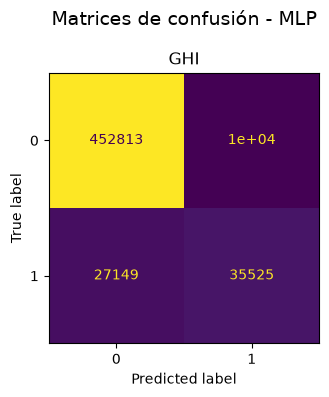

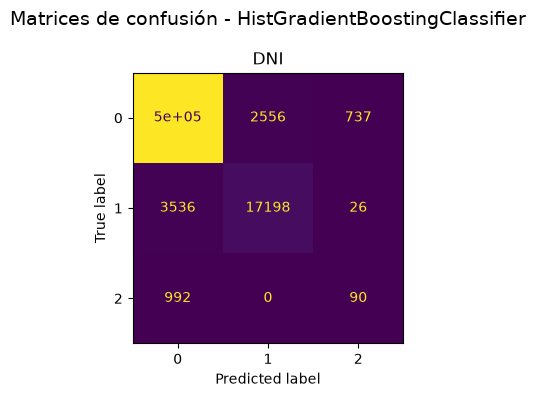

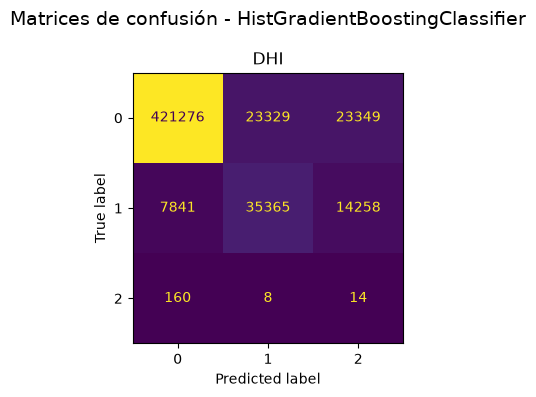

In [82]:
for target in TARGETS:

    plot_confusion_matrices(
        test_df=final_test_df,
        predictions={
            target: final_predictions[target]
        },
        targets=[target],
        model_name=final_model_data[
            target
        ]["model_name"]
    )

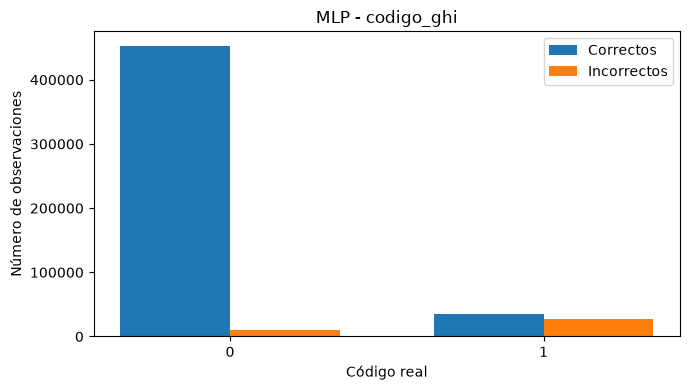

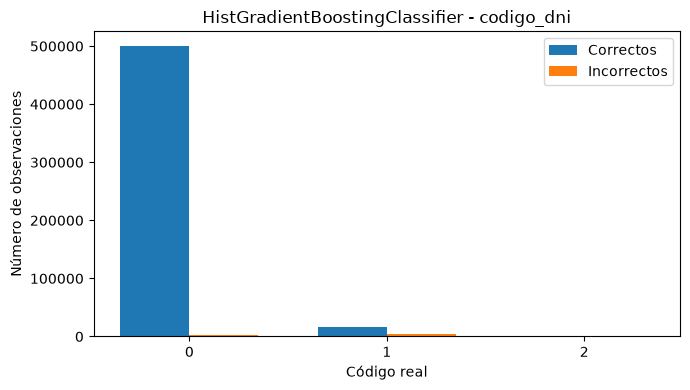

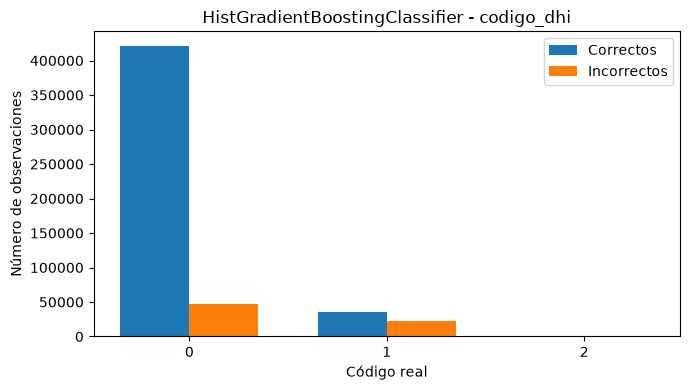

In [83]:
for target in TARGETS:

    plot_correct_predictions_by_class(
        test_df=final_test_df,
        predictions={
            target: final_predictions[target]
        },
        targets=[target],
        model_name=final_model_data[
            target
        ]["model_name"]
    )

El análisis por clase confirma comportamientos diferentes entre los tres targets. En GHI el modelo identifica con gran precisión la clase mayoritaria, mientras que el recall de la clase 1 se sitúa aproximadamente en el 57 %.

En DNI, la clase 1 presenta un comportamiento considerablemente mejor, con cerca del 83 % de observaciones correctamente identificadas. Sin embargo, la clase 2 continúa siendo especialmente difícil y solo se recupera alrededor del 8 % de sus registros.

DHI presenta la principal limitación del sistema: aunque la clase 1 alcanza un recall próximo al 62 %, la clase 2 tiene una presencia extremadamente reducida y solo se identifica correctamente alrededor del 8 %. Estos resultados explican la diferencia existente entre Weighted F1 y Macro F1 y muestran que las clases minoritarias, especialmente el código 2, siguen siendo el principal reto del modelado.

In [84]:
final_results_summary = (
    final_comparison[
        [
            "target",
            "model",
            "n_features",
            "baseline_f1_macro",
            "f1_macro",
            "delta_f1_macro",
            "balanced_accuracy",
            "f1_weighted",
        ]
    ]
    .sort_values(
        "target"
    )
    .reset_index(drop=True)
)

display(
    final_results_summary.round(4)
)

,target,model,n_features,baseline_f1_macro,f1_macro,delta_f1_macro,balanced_accuracy,f1_weighted
0,codigo_dhi,HistGradientBoostingClassifier,21,0.4986,0.5162,0.0176,0.5309,0.9026
1,codigo_dni,HistGradientBoostingClassifier,18,0.5347,0.6448,0.1100,0.6350,0.9847
2,codigo_ghi,MLP,14,0.7435,0.8082,0.0647,0.7725,0.9242


In [85]:
FINAL_RESULTS_SUMMARY_PATH = (
    OPTIMIZATION_OUTPUT_PATH
    / "final_results_summary.parquet"
)

final_results_summary.to_parquet(
    FINAL_RESULTS_SUMMARY_PATH,
    index=False
)

## 15.12. Persistencia y reproducibilidad

Además de los modelos entrenados, se almacena metadata suficiente para reproducir su utilización: modelo seleccionado, experimento de origen, variables utilizadas, hiperparámetros, periodos de entrenamiento y evaluación, rutas de los artefactos y métricas obtenidas sobre 2023.

De esta forma, los artefactos finales pueden reutilizarse sin repetir las fases de selección, optimización y entrenamiento.

In [86]:
FINAL_MODEL_METADATA_PATH = (
    FINAL_MODELS_PATH
    / "model_metadata.json"
)

final_model_metadata = {}

for target, data in final_model_data.items():

    result_row = (
        final_results_summary[
            final_results_summary["target"] == target
        ]
        .iloc[0]
    )

    model_path = {
        "codigo_ghi": GHI_MODEL_PATH,
        "codigo_dni": DNI_MODEL_PATH,
        "codigo_dhi": DHI_MODEL_PATH,
    }[target]

    final_model_metadata[target] = {
        "model": data["model_name"],
        "source_model_id": int(data["model_id"]),
        "train_year": TRAIN_YEAR,
        "test_year": TEST_YEAR,
        "n_features": len(data["features"]),
        "features": list(data["features"]),
        "hyperparameters": final_hyperparameters[target],
        "model_path": str(model_path),
        "scaler_path": (
            str(GHI_SCALER_PATH)
            if target == "codigo_ghi"
            else None
        ),
        "metrics_2023": {
            "f1_macro": float(
                result_row["f1_macro"]
            ),
            "balanced_accuracy": float(
                result_row["balanced_accuracy"]
            ),
            "f1_weighted": float(
                result_row["f1_weighted"]
            ),
        },
    }

In [87]:
with open(
    FINAL_MODEL_METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_model_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    f"Metadata guardada en: "
    f"{FINAL_MODEL_METADATA_PATH}"
)

Metadata guardada en: ..\models\final\model_metadata.json


## 15.13. Conclusiones

La fase de optimización permite obtener una configuración definitiva para cada componente de irradiancia. La validación temporal adicional realizada para GHI demuestra además la importancia de no seleccionar una configuración utilizando una única partición: el MLP inicialmente mejor no coincide con la arquitectura que presenta el mejor comportamiento medio entre estaciones.

Los modelos finales son un MLP para GHI y dos `HistGradientBoostingClassifier` para DNI y DHI. En la comparación interanual sobre 2023 los tres mejoran su Macro F1 de referencia, con incrementos de 0,0647, 0,1100 y 0,0176 respectivamente.

Los resultados muestran un rendimiento especialmente sólido para GHI y una mejora relevante en DNI. En DHI, y especialmente para las clases minoritarias de DNI y DHI, persisten dificultades de clasificación que deben considerarse al interpretar las métricas globales.

Con este proceso quedan fijados los modelos, hiperparámetros, variables de entrada, transformaciones y artefactos que constituyen la solución predictiva final del proyecto.

## 15.14. Persistencia de los resultados finales en bases de datos

Los resultados de los modelos definitivos se integran en las dos capas de almacenamiento utilizadas en el proyecto.

**PostgreSQL** actúa como repositorio estructurado de los modelos finales. Para cada target se almacenan el algoritmo seleccionado, las variables empleadas, los hiperparámetros, los periodos de entrenamiento y evaluación y las métricas globales obtenidas sobre 2023.

**MongoDB** complementa esta información incorporando el comportamiento diario de los modelos a los documentos ya existentes en `daily_summaries`. Para cada fecha de 2023 se almacenan las métricas diarias, las distribuciones real y predicha de las clases y la matriz de confusión.

Los modelos definitivos se identifican mediante el prefijo `FINAL_OPTIMIZED` para diferenciarlos de los experimentos realizados durante las fases anteriores de selección y optimización.

In [88]:
from src.database.postgresql_persistence import (
    save_final_model_result_postgresql,
    get_postgresql_connection,
)

from src.mongodb.mongodb_persistence import (
    save_model_results_mongodb,
)

FINAL_MODEL_TITLES = {
    "codigo_ghi": (
        "FINAL_OPTIMIZED_MLP_GHI"
    ),
    "codigo_dni": (
        "FINAL_OPTIMIZED_HGB_DNI"
    ),
    "codigo_dhi": (
        "FINAL_OPTIMIZED_HGB_DHI"
    ),
}

FINAL_MODEL_TITLES

{'codigo_ghi': 'FINAL_OPTIMIZED_MLP_GHI',
 'codigo_dni': 'FINAL_OPTIMIZED_HGB_DNI',
 'codigo_dhi': 'FINAL_OPTIMIZED_HGB_DHI'}

### 15.14.1. Registro de los modelos finales en PostgreSQL

Cada modelo definitivo se registra como una ejecución diferenciada dentro de `solar.models`, asociada a la versión procesada del dataset y al target correspondiente. Las métricas globales de evaluación se almacenan en `solar.results`.

Los modelos finales se identifican como:

- `FINAL_OPTIMIZED_MLP_GHI`
- `FINAL_OPTIMIZED_HGB_DNI`
- `FINAL_OPTIMIZED_HGB_DHI`

La persistencia se realiza de forma idempotente: si una configuración final ya existe, se actualizan sus características y resultados manteniendo el mismo identificador, evitando generar registros duplicados en sucesivas ejecuciones del notebook.

In [89]:
final_postgresql_model_ids = {}

for target in TARGETS:

    result_row = (
        final_evaluation_results[
            final_evaluation_results[
                "target"
            ] == target
        ]
        .iloc[0]
    )

    db_hyperparameters = {
        "stage": "final_optimized",
        "algorithm": (
            final_model_data[target][
                "model_name"
            ]
        ),
        **final_hyperparameters[
            target
        ],
    }

    model_id = (
        save_final_model_result_postgresql(
            result_row=result_row,
            model_name=(
                FINAL_MODEL_TITLES[
                    target
                ]
            ),
            dataset_version=(
                "processed_dataset_solar_v3"
            ),
            features=(
                final_model_data[
                    target
                ]["features"]
            ),
            hyperparameters=(
                db_hyperparameters
            ),
            train_year=TRAIN_YEAR,
            test_year=TEST_YEAR,
        )
    )

    final_postgresql_model_ids[
        target
    ] = model_id

final_postgresql_model_ids

{'codigo_ghi': 25, 'codigo_dni': 26, 'codigo_dhi': 27}

Los tres modelos definitivos quedan registrados correctamente en PostgreSQL con identificadores propios y nombres diferenciados respecto a los experimentos anteriores.

PostgreSQL conserva así el resumen global de la solución predictiva final: target, periodo de entrenamiento y evaluación, número y listado de variables, hiperparámetros y métricas obtenidas sobre 2023.

### 15.14.2. Persistencia de resultados diarios en MongoDB

Una vez registrados los modelos finales en PostgreSQL, sus identificadores se utilizan como referencia para incorporar los resultados diarios de la evaluación en MongoDB.

La persistencia se realiza sobre los documentos correspondientes a 2023. Para cada fecha y target se almacenan las métricas de clasificación, la distribución real y predicha de las clases y la matriz de confusión.

Los resultados se incorporan al bloque `resultados_modelos.ejecuciones` de los documentos existentes en `daily_summaries`. Cada ejecución queda asociada tanto al target como al identificador del modelo almacenado en PostgreSQL, manteniendo así la trazabilidad entre ambas bases de datos.

La operación utiliza un mecanismo de actualización que permite repetir el proceso sin generar ejecuciones duplicadas para una misma combinación de modelo y target.

In [90]:
mongodb_final_results = {}

for target in TARGETS:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"{FINAL_MODEL_TITLES[target]}"
    )

    print(
        "=" * 70
    )

    result = save_model_results_mongodb(
        test_df=final_test_df,
        predictions={
            target: (
                final_predictions[
                    target
                ]
            )
        },
        model_name=(
            FINAL_MODEL_TITLES[
                target
            ]
        ),
        model_ids_by_target={
            target: (
                final_postgresql_model_ids[
                    target
                ]
            )
        },
        dataset_version="v3",
        features=(
            final_model_data[
                target
            ]["features"]
        ),
        targets=[target],
        train_year=TRAIN_YEAR,
        test_year=TEST_YEAR,
        collection_name=(
            "daily_summaries"
        ),
    )

    mongodb_final_results[
        target
    ] = result


FINAL_OPTIMIZED_MLP_GHI


c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sk

Días procesados correctamente: 365
Días con error: 0

FINAL_OPTIMIZED_HGB_DNI


c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sk

Días procesados correctamente: 365
Días con error: 0

FINAL_OPTIMIZED_HGB_DHI


c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, 

Días procesados correctamente: 365
Días con error: 0


c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [91]:
mongodb_persistence_summary = []

for target, result in (
    mongodb_final_results.items()
):

    mongodb_persistence_summary.append({
        "target": target,
        "model": (
            FINAL_MODEL_TITLES[
                target
            ]
        ),
        "postgresql_model_id": (
            final_postgresql_model_ids[
                target
            ]
        ),
        "success_days": len(
            result["success"]
        ),
        "error_days": len(
            result["errors"]
        ),
    })

mongodb_persistence_summary = (
    pd.DataFrame(
        mongodb_persistence_summary
    )
)

display(
    mongodb_persistence_summary
)

,target,model,postgresql_model_id,success_days,error_days
0,codigo_ghi,FINAL_OPTIMIZED_MLP_GHI,25,365,0
1,codigo_dni,FINAL_OPTIMIZED_HGB_DNI,26,365,0
2,codigo_dhi,FINAL_OPTIMIZED_HGB_DHI,27,365,0


La persistencia de los modelos finales en MongoDB se completa correctamente para los 365 días de 2023.

Cada documento diario incorpora una ejecución independiente para el modelo asociado a GHI, DNI y DHI. Las ejecuciones quedan vinculadas mediante el identificador del modelo almacenado en PostgreSQL, manteniendo así la trazabilidad entre la evaluación global relacional y los resultados diarios almacenados en la capa documental.

La ausencia de errores durante la carga confirma que las predicciones finales tienen correspondencia completa con los documentos diarios utilizados para la evaluación interanual.